# LSTM Forecasting for WTI Crude Oil Futures

## Project Overview
This notebook implements a **Long Short-Term Memory (LSTM)** neural network to forecast WTI crude oil futures returns at multiple horizons (1-day, 5-day, and 20-day). The model uses 31 macroeconomic indicators from the FRED-MD database plus daily price momentum as input features.

### Key Design Decisions
- **Why LSTM?** Unlike Elastic Net and XGBoost which flatten the 30-day lookback into a single row, LSTM processes the temporal sequence natively — preserving the order and dynamics of how macro variables and prices evolve over the lookback window.
- **Why log returns (not prices)?** Raw prices are non-stationary and scale-dependent. Log returns are stationary, comparable across time periods, and prevent the model from achieving false accuracy by simply learning "tomorrow ≈ today."
- **Why multiple horizons?** Monthly macro data may lack signal at daily frequency but could be predictive at weekly (h=5) or monthly (h=20) horizons where the data frequency aligns with the target.

### Preprocessing Pipeline
1. FRED-MD macro data shifted by 1 month (anti-leakage: month *m* data available at month *m+1*)
2. Macro aligned to WTI trading days via forward-fill (no synthetic weekends)
3. 30-day sliding window → 3D input: `(samples, 30 timesteps, 32 features)`
4. StandardScaler fit on training data only (per CV fold)
5. TimeSeriesSplit with 5 folds for hyperparameter selection

### Abstract Class
The `LSTMForecastModel` follows the same `BaseForecastModel` abstract class used by our Elastic Net, XGBoost, and VAR implementations, ensuring consistent interface across all models.

## 1. Imports and Dependencies
Load all required libraries. We use PyTorch as the primary deep learning framework (with TensorFlow/Keras as fallback), scikit-learn for cross-validation and scaling, and standard data science libraries.

In [2]:
# ============================================================
# Imports
# ============================================================
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import warnings
import itertools
import os
import time
from abc import ABC, abstractmethod
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

## 2. Deep Learning Framework Detection
Attempt to import PyTorch first (preferred for transparency and debugging), falling back to TensorFlow/Keras if unavailable. This makes the notebook portable across environments.

In [3]:
# ============================================================
# Framework Detection
# ============================================================
# PyTorch is preferred for its explicit control over training loops,
# gradient clipping, and model state management. Keras is supported
# as a fallback for environments without PyTorch.
FRAMEWORK = None
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    FRAMEWORK = "pytorch"
except ImportError:
    try:
        os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # suppress TF warnings
        import tensorflow as tf
        from tensorflow import keras
        FRAMEWORK = "keras"
    except ImportError:
        raise ImportError(
            "Neither PyTorch nor TensorFlow is installed.\n"
            "  pip install torch\n  pip install tensorflow"
        )
print(f"[LSTM] Using framework: {FRAMEWORK}")

[LSTM] Using framework: pytorch


## 3. Base Forecast Model (Abstract Class)
All models in this project (Elastic Net, XGBoost, VAR, LSTM) inherit from this abstract class to ensure a consistent interface with `fit()`, `predict()`, `evaluate()`, `save()`, and `load()` methods.

In [4]:
# ============================================================
# Base Forecast Model — Abstract Class
# ============================================================
class BaseForecastModel(ABC):
    """
    Abstract base class for all forecasting models in this project.
    Enforces a consistent API: fit, predict, evaluate, save, load.
    """
    def __init__(self, task_type: str):
        self.task_type = task_type  # "regression" for all return-forecasting models

    @abstractmethod
    def fit(self, *args, **kwargs):
        """Train the model on provided data."""
        pass

    @abstractmethod
    def predict(self, X):
        """Generate predictions for input X."""
        pass

    @abstractmethod
    def evaluate(self, X, y):
        """Compute evaluation metrics on (X, y)."""
        pass

    @abstractmethod
    def save(self, filepath: str):
        """Serialize model to disk."""
        pass

    @abstractmethod
    def load(self, filepath: str):
        """Deserialize model from disk."""
        pass

## 4. Evaluation Metrics
We use four metrics to assess model performance:
- **RMSE** — penalizes large errors heavily; primary optimization target
- **MAE** — more robust to outliers than RMSE
- **R²** — proportion of variance explained; negative means worse than predicting the mean
- **Directional Accuracy** — fraction of days where the model correctly predicts the sign of the return (up vs. down); 50% = random baseline

In [5]:
# ============================================================
# Evaluation Metrics
# ============================================================
def rmse(y, yhat):
    """Root Mean Squared Error."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    """Mean Absolute Error."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    """R-squared (coefficient of determination).
    Returns negative values when predictions are worse than the mean."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    """Fraction of samples where predicted and actual signs match.
    50% = random baseline (coin flip)."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.sign(y) == np.sign(yhat)))

## 5. Data Loading Helpers (Anti-Leakage)
These functions handle loading FRED-MD macroeconomic data and WTI price data with **strict leakage prevention**:
- Macro data for month *m* is shifted to month *m+1* — because in reality, January's GDP isn't published until February
- Macro is forward-filled onto trading days only (no synthetic weekend/holiday rows)
- Target is the h-day-ahead log return: `y_t = log(P_{t+h}) - log(P_t)`

In [6]:
# ============================================================
# Data Helpers (STRICT leakage control)
# ============================================================
def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    """Load FRED-MD monthly macro data, keeping only specified features.

    Args:
        path: Path to FRED-MD CSV (e.g., 2025-12-MD.csv)
        features: List of column names to retain

    Returns:
        DataFrame indexed by date with selected macro features
    """
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")
    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    """Load WTI crude oil futures daily price data from Investing.com CSV.

    Returns:
        Series indexed by date with 'Price' values (trading days only)
    """
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()


def make_target(price: pd.Series, horizon: int = 1) -> pd.Series:
    """Compute h-day-ahead log return target.

    y_t = log(P_{t+h}) - log(P_t)

    Args:
        price: Daily price series
        horizon: Forecast horizon in trading days (1=daily, 5=weekly, 20=monthly)

    Returns:
        Series of log returns, with NaN at the end where P_{t+h} doesn't exist
    """
    price = price.astype(float)
    return (np.log(price.shift(-horizon)) - np.log(price)).rename("y")

## 6. 3D Sequence Builder
Unlike Elastic Net and XGBoost which flatten the lookback window into a wide feature vector (e.g., `RPI_lag01, RPI_lag02, ...`), the LSTM takes 3D input: `(samples, timesteps, features)`. This preserves temporal ordering — the model sees how each feature evolves over the 30-day window.

For horizons > 1 (h=5, h=20), consecutive samples share overlapping target windows. This is standard practice in the literature (e.g., Welch & Goyal, 2008) but should be noted when interpreting R² — it can appear inflated due to autocorrelation in the target.

In [7]:
# ============================================================
# 3D Sequence Builder (multi-horizon aware)
# ============================================================
def build_sequences(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    """Build 3D sliding-window sequences for LSTM.

    Pipeline:
        1. Load monthly macro → shift by 1 month (anti-leakage)
        2. Load daily prices → align macro via forward-fill
        3. Add daily log return (ret_1d) as a feature
        4. Create sliding windows of length `lookback`
        5. Split chronologically into train / val / test

    Args:
        macro_file: Path to FRED-MD CSV
        price_file: Path to WTI price CSV
        features: List of macro feature names
        lookback: Number of past trading days in each sequence (default 30)
        horizon: Forecast horizon in trading days
        train_end: Last date of training set
        val_end: Last date of validation set

    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test (numpy arrays)
        dates_train, dates_val, dates_test (DatetimeIndex)
        feat_cols (list of feature names)
    """
    # Load macro and apply 1-month publication lag (anti-leakage)
    macro_m = load_macro_monthly(macro_file, features)
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # Load price — trading days only, no synthetic weekends
    price = load_price(price_file)

    # Align macro to trading-day index via forward-fill
    macro_d = macro_m.reindex(price.index, method="ffill")

    # Build base dataframe with price and macro aligned
    base = macro_d.join(price, how="inner").dropna()
    base["ret_1d"] = np.log(base["Price"]).diff()  # daily log return as feature
    base = base.dropna()

    # Feature columns: all macro + daily return
    feat_cols = [c for c in features if c in base.columns] + ["ret_1d"]

    feature_data = base[feat_cols].values      # shape: (T, n_features)
    target_data = make_target(base["Price"], horizon=horizon).values
    dates = base.index

    # Build sliding window sequences: each sample is (lookback, n_features)
    X_list, y_list, d_list = [], [], []
    for i in range(lookback, len(feature_data)):
        if i < len(target_data) and np.isfinite(target_data[i]):
            X_list.append(feature_data[i - lookback : i])
            y_list.append(target_data[i])
            d_list.append(dates[i])

    X_all = np.array(X_list, dtype=np.float32)  # (N, lookback, n_features)
    y_all = np.array(y_list, dtype=np.float32)   # (N,)
    d_all = pd.DatetimeIndex(d_list)

    # Chronological split
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts   = pd.Timestamp(val_end)

    tr = d_all <= train_end_ts
    va = (d_all > train_end_ts) & (d_all <= val_end_ts)
    te = d_all > val_end_ts

    return (
        X_all[tr], y_all[tr],
        X_all[va], y_all[va],
        X_all[te], y_all[te],
        d_all[tr], d_all[va], d_all[te],
        feat_cols,
    )

## 7. 3D StandardScaler Utility
Standard scaling is critical for LSTM — without it, features on different scales (e.g., S&P 500 at ~5000 vs. FEDFUNDS at ~5.0) dominate the gradients. We reshape 3D arrays to 2D for sklearn's StandardScaler, then reshape back. The scaler is always **fit on training data only** to prevent information leakage.

In [8]:
# ============================================================
# 3D StandardScaler
# ============================================================
def scale_3d(X_train, X_val=None, X_test=None):
    """Fit StandardScaler on X_train (3D), transform all splits.

    Reshapes (N, T, F) → (N*T, F) for sklearn, then back.
    Scaler is fit ONLY on X_train to prevent leakage.

    Returns:
        Tuple of scaled arrays + fitted scaler
    """
    n, T, F = X_train.shape
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, F))  # fit on train only

    def _tx(X):
        return scaler.transform(X.reshape(-1, F)).reshape(X.shape[0], T, F).astype(np.float32)

    out = [_tx(X_train)]
    if X_val is not None:
        out.append(_tx(X_val))
    if X_test is not None:
        out.append(_tx(X_test))
    return tuple(out) + (scaler,)

## 8. LSTM Neural Network Architecture & Training Backend
The LSTM architecture:
- **Input**: `(batch, 30 timesteps, 32 features)` — the past 30 trading days of macro + price data
- **LSTM layers**: 1 or 2 stacked layers with configurable hidden size (32/64/128)
- **Output head**: Dropout → Linear(hidden_size, 1) — predicts a single scalar (log return)
- **Training**: Adam optimizer with weight decay (1e-5), gradient clipping at 1.0, MSE loss
- **Early stopping**: patience=20 epochs on validation RMSE to prevent overfitting

Both PyTorch and Keras backends are implemented — the code auto-selects based on available framework.

In [9]:
# ============================================================
# PyTorch Backend
# ============================================================
if FRAMEWORK == "pytorch":

    class LSTMNet(nn.Module):
        """LSTM network for time series regression.

        Architecture: Stacked LSTM → Dropout → Linear(1)
        Uses the last timestep's hidden state for prediction.
        """
        def __init__(self, input_size, hidden_size, num_layers, dropout):
            super().__init__()
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,  # inter-layer dropout
                batch_first=True,
            )
            self.head = nn.Sequential(
                nn.Dropout(dropout),       # regularization before output
                nn.Linear(hidden_size, 1), # single scalar output
            )

        def forward(self, x):
            # x: (batch, seq_len, input_size)
            out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_size)
            return self.head(out[:, -1, :]).squeeze(-1)  # last timestep → scalar

    def _train_lstm_pytorch(
        X_train, y_train, X_val, y_val,
        hidden_size, num_layers, dropout, lr,
        batch_size, epochs, patience, device,
    ):
        """Train one LSTM configuration with early stopping.

        Returns:
            (trained_model, best_validation_rmse)
        """
        input_size = X_train.shape[2]
        model = LSTMNet(input_size, hidden_size, num_layers, dropout).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
        criterion = nn.MSELoss()

        # Create DataLoaders (shuffle=False for time series)
        train_ds = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.float32),
        )
        val_ds = TensorDataset(
            torch.tensor(X_val, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.float32),
        )
        train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
        val_dl   = DataLoader(val_ds,   batch_size=batch_size * 2, shuffle=False)

        best_val_loss, best_state, wait = np.inf, None, 0

        for epoch in range(1, epochs + 1):
            # --- Training pass ---
            model.train()
            for xb, yb in train_dl:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stabilize training
                optimizer.step()

            # --- Validation pass ---
            model.eval()
            preds = []
            with torch.no_grad():
                for xb, _ in val_dl:
                    preds.append(model(xb.to(device)).cpu().numpy())
            val_loss = float(np.sqrt(np.mean((y_val - np.concatenate(preds)) ** 2)))

            # --- Early stopping ---
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break

        # Restore best weights
        if best_state:
            model.load_state_dict(best_state)
        model.eval()
        return model, best_val_loss

    def _predict_pytorch(model, X_scaled, device):
        """Generate predictions from a trained PyTorch LSTM."""
        model.eval()
        with torch.no_grad():
            xt = torch.tensor(X_scaled, dtype=torch.float32).to(device)
            return model(xt).cpu().numpy()

    def _save_model_pytorch(model, best_params):
        """Serialize PyTorch model weights and config for pickle."""
        return {
            "state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
            "config": {
                "input_size": model.lstm.input_size,
                "hidden_size": best_params["hidden_size"],
                "num_layers": best_params["num_layers"],
                "dropout": best_params["dropout"],
            },
        }

    def _load_model_pytorch(model_data, device):
        """Reconstruct PyTorch LSTM from saved weights."""
        cfg = model_data["config"]
        model = LSTMNet(
            cfg["input_size"], cfg["hidden_size"],
            cfg["num_layers"], cfg["dropout"],
        ).to(device)
        model.load_state_dict(model_data["state_dict"])
        model.eval()
        return model

    # Assign framework-agnostic function names
    train_lstm    = _train_lstm_pytorch
    predict_fn    = _predict_pytorch
    save_model_fn = _save_model_pytorch
    load_model_fn = _load_model_pytorch

# ============================================================
# Keras Backend (fallback)
# ============================================================
elif FRAMEWORK == "keras":

    def _build_keras_model(input_shape, hidden_size, num_layers, dropout, lr):
        """Build a Keras LSTM model with specified architecture."""
        model = keras.Sequential()
        for i in range(num_layers):
            return_seq = (i < num_layers - 1)
            model.add(keras.layers.LSTM(
                hidden_size,
                return_sequences=return_seq,
                input_shape=input_shape if i == 0 else None,
            ))
            model.add(keras.layers.Dropout(dropout))
        model.add(keras.layers.Dense(1))
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def _train_lstm_keras(
        X_train, y_train, X_val, y_val,
        hidden_size, num_layers, dropout, lr,
        batch_size, epochs, patience, device,
    ):
        """Train one Keras LSTM config with EarlyStopping callback."""
        input_shape = (X_train.shape[1], X_train.shape[2])
        model = _build_keras_model(input_shape, hidden_size, num_layers, dropout, lr)
        es = keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True
        )
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs, batch_size=batch_size,
            callbacks=[es], verbose=0,
        )
        val_pred = model.predict(X_val, verbose=0).flatten()
        val_rmse = float(np.sqrt(np.mean((y_val - val_pred) ** 2)))
        return model, val_rmse

    def _predict_keras(model, X_scaled, device):
        return model.predict(X_scaled, verbose=0).flatten()

    def _save_model_keras(model, best_params):
        return {
            "weights": model.get_weights(),
            "config": {
                "input_shape": (model.input_shape[1], model.input_shape[2]),
                "hidden_size": best_params["hidden_size"],
                "num_layers": best_params["num_layers"],
                "dropout": best_params["dropout"],
                "lr": best_params["lr"],
            },
        }

    def _load_model_keras(model_data, device):
        cfg = model_data["config"]
        model = _build_keras_model(
            cfg["input_shape"], cfg["hidden_size"],
            cfg["num_layers"], cfg["dropout"], cfg["lr"],
        )
        model.set_weights(model_data["weights"])
        return model

    train_lstm    = _train_lstm_keras
    predict_fn    = _predict_keras
    save_model_fn = _save_model_keras
    load_model_fn = _load_model_keras

## 9. LSTM Forecast Model Class
This is the main model class, inheriting from `BaseForecastModel`. It orchestrates:
1. **Hyperparameter search** via TimeSeriesSplit CV (5 folds) over a grid of hidden sizes, layer counts, dropout rates, and learning rates (24 configs × 5 folds = 120 total fits)
2. **Final retraining** on the full training set using the best config, with the last 10% held out as an internal early-stopping set
3. **Prediction** and **evaluation** using the fitted scaler and model

In [10]:
# ============================================================
# LSTM Forecast Model (follows BaseForecastModel)
# ============================================================
class LSTMForecastModel(BaseForecastModel):
    """LSTM for WTI log-return forecasting at configurable horizons.

    Hyperparameter grid search via TimeSeriesSplit CV.
    Final model retrained on full training data with last 10%
    held out for early stopping.

    Attributes:
        horizon: Forecast horizon in trading days
        best_params_: Best hyperparameters found by CV
        cv_results_: Full CV results for all configurations
        model_: Trained LSTM network
        scaler_: Fitted StandardScaler
    """

    def __init__(
        self,
        horizon: int = 1,
        lookback: int = 30,
        n_splits: int = 5,
        epochs: int = 200,
        patience: int = 20,
        batch_size: int = 128,
        device: str = None,
        hidden_sizes: list[int]    = None,
        num_layers_list: list[int] = None,
        dropouts: list[float]      = None,
        learning_rates: list[float] = None,
    ):
        super().__init__("regression")
        self.horizon      = horizon
        self.lookback     = lookback
        self.n_splits     = n_splits
        self.epochs       = epochs
        self.patience     = patience
        self.batch_size   = batch_size

        if FRAMEWORK == "pytorch":
            self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = "cpu"

        # Hyperparameter grid — 24 configs by default
        self.hidden_sizes    = hidden_sizes    or [32, 64, 128]
        self.num_layers_list = num_layers_list or [1, 2]
        self.dropouts        = dropouts        or [0.1, 0.3]
        self.learning_rates  = learning_rates  or [1e-3, 5e-4]

        # Populated by fit()
        self.model_       = None
        self.scaler_      = None
        self.best_params_ = None
        self.cv_results_  = []
        self.feature_names_ = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        """Run CV grid search, then retrain final model on full training data.

        Args:
            X_train: 3D array (n_samples, lookback, n_features)
            y_train: 1D array (n_samples,)
        """
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        grid = list(itertools.product(
            self.hidden_sizes, self.num_layers_list,
            self.dropouts, self.learning_rates,
        ))

        print(f"\n[LSTM h={self.horizon}] CV grid search: {len(grid)} configs × "
              f"{self.n_splits} folds = {len(grid) * self.n_splits} fits")
        best_rmse = np.inf
        best_cfg  = None

        for idx, (hs, nl, do, lr) in enumerate(grid):
            fold_rmses = []
            for tr_idx, va_idx in tscv.split(X_train):
                Xtr, Xva = X_train[tr_idx], X_train[va_idx]
                ytr, yva = y_train[tr_idx], y_train[va_idx]
                Xtr_s, Xva_s, _ = scale_3d(Xtr, Xva)  # scale per fold

                _, val_rmse = train_lstm(
                    Xtr_s, ytr, Xva_s, yva,
                    hidden_size=hs, num_layers=nl, dropout=do, lr=lr,
                    batch_size=self.batch_size, epochs=self.epochs,
                    patience=self.patience, device=self.device,
                )
                fold_rmses.append(val_rmse)

            mean_rmse = np.mean(fold_rmses)
            cfg = {"hidden_size": hs, "num_layers": nl, "dropout": do, "lr": lr}
            self.cv_results_.append({**cfg, "cv_rmse": mean_rmse})
            print(f"  [{idx+1:2d}/{len(grid)}] hs={hs:3d} nl={nl} "
                  f"do={do:.1f} lr={lr:.0e} → CV RMSE: {mean_rmse:.6f}")

            if mean_rmse < best_rmse:
                best_rmse = mean_rmse
                best_cfg  = cfg

        self.best_params_ = {**best_cfg, "cv_rmse": best_rmse}
        print(f"[LSTM h={self.horizon}] Best: {self.best_params_}")

        # --- Final retraining on all training data ---
        # Hold out last 10% for early stopping only
        n = len(X_train)
        split = int(n * 0.9)
        Xtr_f, Xva_f = X_train[:split], X_train[split:]
        ytr_f, yva_f = y_train[:split], y_train[split:]

        # Fit scaler on ALL training data
        _, T, F = X_train.shape
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X_train.reshape(-1, F))

        Xtr_s = self.scaler_.transform(Xtr_f.reshape(-1, F)).reshape(len(Xtr_f), T, F).astype(np.float32)
        Xva_s = self.scaler_.transform(Xva_f.reshape(-1, F)).reshape(len(Xva_f), T, F).astype(np.float32)

        self.model_, _ = train_lstm(
            Xtr_s, ytr_f, Xva_s, yva_f,
            hidden_size=best_cfg["hidden_size"],
            num_layers=best_cfg["num_layers"],
            dropout=best_cfg["dropout"],
            lr=best_cfg["lr"],
            batch_size=self.batch_size,
            epochs=self.epochs,
            patience=self.patience,
            device=self.device,
        )
        print(f"[LSTM h={self.horizon}] Final model trained.\n")
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Generate predictions. Applies stored scaler before inference."""
        n, T, F = X.shape
        X_s = self.scaler_.transform(X.reshape(-1, F)).reshape(n, T, F).astype(np.float32)
        return predict_fn(self.model_, X_s, self.device)

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> dict:
        """Compute all evaluation metrics."""
        p = self.predict(X)
        return {
            "rmse":  rmse(y, p),
            "mae":   mae(y, p),
            "r2":    r2(y, p),
            "directional_acc": directional_accuracy(y, p),
        }

    def save(self, path: str):
        """Save model weights, scaler, and CV results to pickle."""
        state = {
            "framework": FRAMEWORK, "horizon": self.horizon,
            "best_params_": self.best_params_, "cv_results_": self.cv_results_,
            "scaler_": self.scaler_, "feature_names_": self.feature_names_,
            "lookback": self.lookback,
            "model_data": save_model_fn(self.model_, self.best_params_)
                          if self.model_ is not None else None,
        }
        with open(path, "wb") as f:
            pickle.dump(state, f)
        print(f"[LSTM h={self.horizon}] Saved → {path}")

    def load(self, path: str):
        """Load model from pickle file."""
        with open(path, "rb") as f:
            state = pickle.load(f)
        self.horizon = state.get("horizon", 1)
        self.best_params_ = state["best_params_"]
        self.cv_results_ = state["cv_results_"]
        self.scaler_ = state["scaler_"]
        self.feature_names_ = state.get("feature_names_")
        self.lookback = state.get("lookback", 30)
        if state.get("model_data"):
            self.model_ = load_model_fn(state["model_data"], self.device)
        print(f"[LSTM h={self.horizon}] Loaded ← {path}")

## 10. Exploratory Data Analysis
Inspect the raw data before modeling: shape, date ranges, missing values, and return distribution statistics. The multi-horizon return stats help set expectations — note how standard deviation scales roughly as √h (e.g., daily std ≈ 0.025, 20-day std ≈ 0.100 ≈ 0.025 × √20), consistent with a random walk.

In [11]:
# ============================================================
# EDA
# ============================================================
def run_eda(macro_file: Path, price_file: Path, features: list[str]):
    """Print comprehensive data summary: shapes, date ranges, missing values,
    and return distribution statistics at multiple horizons."""
    print("=" * 60)
    print("EDA: Macro + Price Data Inspection")
    print("=" * 60)

    macro_m = load_macro_monthly(macro_file, features)
    print(f"\n[Macro Monthly] Shape: {macro_m.shape}")
    print(f"  Date range : {macro_m.index.min()} → {macro_m.index.max()}")
    pct_miss = (macro_m.isna().sum() / len(macro_m) * 100).round(2)
    if pct_miss.any():
        print(f"  Missing (%):\n{pct_miss[pct_miss > 0].to_string()}")
    else:
        print("  Missing: None")

    price = load_price(price_file)
    print(f"\n[WTI Price] Length: {len(price)}")
    print(f"  Date range : {price.index.min()} → {price.index.max()}")
    print(f"  Missing    : {price.isna().sum()}")

    ret = np.log(price.astype(float)).diff().dropna()
    print(f"\n[Daily Log Returns] n={len(ret)}")
    print(f"  Mean : {ret.mean():.6f}")
    print(f"  Std  : {ret.std():.6f}")
    print(f"  Skew : {ret.skew():.4f}")
    print(f"  Kurt : {ret.kurtosis():.4f}")
    print(f"  Range: [{ret.min():.4f}, {ret.max():.4f}]")

    for h in [1, 5, 20]:
        rh = (np.log(price.astype(float).shift(-h)) - np.log(price.astype(float))).dropna()
        print(f"\n[{h}-day Log Returns] n={len(rh)}")
        print(f"  Mean : {rh.mean():.6f}   Std: {rh.std():.6f}   "
              f"Skew: {rh.skew():.4f}   Kurt: {rh.kurtosis():.4f}")
    print("=" * 60)

# --- Run EDA ---
MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
PRICE_FILE = Path("Price/Price.csv")
FEATURES = [
    "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
    "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
    "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
    "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
    "PPICMM","UMCSENTx"
]

run_eda(MACRO_FILE, PRICE_FILE, FEATURES)

EDA: Macro + Price Data Inspection

[Macro Monthly] Shape: (803, 31)
  Date range : 1959-01-01 00:00:00 → 2025-11-01 00:00:00
  Missing (%):
RPI              0.25
W875RX1          0.25
CMRMTSPLx        0.25
CONSPI           0.25
S&P PE ratio     0.12
PPICMM           0.25
UMCSENTx        19.18

[WTI Price] Length: 10835
  Date range : 1983-03-31 00:00:00 → 2025-10-31 00:00:00
  Missing    : 0

[Daily Log Returns] n=10834
  Mean : 0.000068
  Std  : 0.025474
  Skew : -0.6516
  Kurt : 60.4536
  Range: [-0.5686, 0.5812]

[1-day Log Returns] n=10834
  Mean : 0.000068   Std: 0.025474   Skew: -0.6516   Kurt: 60.4536

[5-day Log Returns] n=10830
  Mean : 0.000330   Std: 0.052597   Skew: -0.8044   Kurt: 12.6432

[20-day Log Returns] n=10815
  Mean : 0.001251   Std: 0.100311   Skew: -0.5089   Kurt: 6.4150


## 11. Multi-Horizon Training
Train the LSTM at three forecast horizons: 1-day, 5-day, and 20-day. For each horizon:
1. Build 3D sequences with the appropriate target
2. Run 24-config × 5-fold CV grid search to find optimal hyperparameters
3. Retrain on full training set with best config
4. Evaluate on validation and test sets
5. Store **all** data and predictions in the `results` dict for downstream plotting

**Important**: This is the most time-consuming cell (~45 min on CPU, ~15 min on GPU). All subsequent plot cells reference the `results` dict directly — no reloading needed.

In [12]:
# ============================================================
# Multi-Horizon Training Loop
# ============================================================
# All data, predictions, metrics, and models are stored in `results`
# so that plot cells can reference them directly without reloading.

HORIZONS = [1, 5, 20]
results = {}  # {horizon: {Xtr, ytr, ..., pred_val, pred_test, model, ...}}

for h in HORIZONS:
    print(f"\n{'='*60}")
    print(f"  HORIZON = {h} day(s)")
    print(f"{'='*60}")
    t0 = time.time()

    # Build 3D sequences for this horizon
    (Xtr, ytr, Xva, yva, Xte, yte,
     dtr, dva, dte, feat_cols) = build_sequences(
        MACRO_FILE, PRICE_FILE, FEATURES,
        lookback=30, horizon=h,
        train_end="2014-12-31", val_end="2024-12-31",
    )

    print(f"\nSequence shapes (h={h}):")
    print(f"  Train: X={Xtr.shape}  y={ytr.shape}  ({dtr.min().date()} → {dtr.max().date()})")
    print(f"  Val  : X={Xva.shape}  y={yva.shape}  ({dva.min().date()} → {dva.max().date()})")
    print(f"  Test : X={Xte.shape}  y={yte.shape}  ({dte.min().date()} → {dte.max().date()})")
    print(f"  y_train — mean: {ytr.mean():.6f}  std: {ytr.std():.6f}")
    print(f"  y_val   — mean: {yva.mean():.6f}  std: {yva.std():.6f}")
    print(f"  y_test  — mean: {yte.mean():.6f}  std: {yte.std():.6f}")

    # Fit LSTM with CV grid search
    model = LSTMForecastModel(
        horizon=h, lookback=30, n_splits=5, epochs=200, patience=20,
        batch_size=128,
        hidden_sizes=[32, 64, 128], num_layers_list=[1, 2],
        dropouts=[0.1, 0.3], learning_rates=[1e-3, 5e-4],
    )
    model.feature_names_ = feat_cols
    model.fit(Xtr, ytr)

    # Generate predictions and metrics
    pred_val  = model.predict(Xva)
    pred_test = model.predict(Xte)
    val_metrics  = model.evaluate(Xva, yva)
    test_metrics = model.evaluate(Xte, yte)
    elapsed = time.time() - t0

    # Store everything for plotting
    results[h] = {
        'Xtr': Xtr, 'ytr': ytr,
        'Xva': Xva, 'yva': yva,
        'Xte': Xte, 'yte': yte,
        'dtr': dtr, 'dva': dva, 'dte': dte,
        'pred_val': pred_val, 'pred_test': pred_test,
        'val_metrics': val_metrics, 'test_metrics': test_metrics,
        'model': model, 'elapsed': elapsed,
    }

    print(f"Validation (h={h}): {val_metrics}")
    print(f"Test       (h={h}): {test_metrics}")
    print(f"Time: {elapsed/60:.1f} min")
    model.save(f"lstm_wti_h{h}.pkl")

print(f"\n{'='*60}")
print("All horizons complete. Results stored in `results` dict.")
print(f"{'='*60}")


  HORIZON = 1 day(s)

Sequence shapes (h=1):
  Train: X=(7953, 30, 32)  y=(7953,)  (1983-05-16 → 2014-12-31)
  Val  : X=(2635, 30, 32)  y=(2635,)  (2015-01-01 → 2024-12-31)
  Test : X=(215, 30, 32)  y=(215,)  (2025-01-02 → 2025-10-30)
  y_train — mean: 0.000075  std: 0.023593
  y_val   — mean: 0.000108  std: 0.030870
  y_test  — mean: -0.000805  std: 0.020503

[LSTM h=1] CV grid search: 24 configs × 5 folds = 120 fits
  [ 1/24] hs= 32 nl=1 do=0.1 lr=1e-03 → CV RMSE: 0.048388
  [ 2/24] hs= 32 nl=1 do=0.1 lr=5e-04 → CV RMSE: 0.040095
  [ 3/24] hs= 32 nl=1 do=0.3 lr=1e-03 → CV RMSE: 0.026911
  [ 4/24] hs= 32 nl=1 do=0.3 lr=5e-04 → CV RMSE: 0.030615
  [ 5/24] hs= 32 nl=2 do=0.1 lr=1e-03 → CV RMSE: 0.023895
  [ 6/24] hs= 32 nl=2 do=0.1 lr=5e-04 → CV RMSE: 0.025300
  [ 7/24] hs= 32 nl=2 do=0.3 lr=1e-03 → CV RMSE: 0.024694
  [ 8/24] hs= 32 nl=2 do=0.3 lr=5e-04 → CV RMSE: 0.023797
  [ 9/24] hs= 64 nl=1 do=0.1 lr=1e-03 → CV RMSE: 0.030550
  [10/24] hs= 64 nl=1 do=0.1 lr=5e-04 → CV RMSE: 0.0357

## 12. Multi-Horizon Comparison Table
Print a formatted comparison of all metrics across horizons and splits. This table is the core result for the report — it shows whether increasing the forecast horizon improves predictability when using monthly macro features.

In [13]:
# ============================================================
# Comparison Table
# ============================================================
print("\n" + "=" * 80)
print("  LSTM MULTI-HORIZON COMPARISON")
print("=" * 80)

header = f"{'Horizon':>8} | {'Split':>5} | {'RMSE':>10} | {'MAE':>10} | {'R²':>10} | {'Dir Acc':>10}"
print(header)
print("-" * len(header))

for h in HORIZONS:
    r = results[h]
    for split_name, metrics in [("Val", r["val_metrics"]), ("Test", r["test_metrics"])]:
        print(f"  h={h:>2}d   | {split_name:>5} | "
              f"{metrics['rmse']:>10.6f} | "
              f"{metrics['mae']:>10.6f} | "
              f"{metrics['r2']:>10.6f} | "
              f"{metrics['directional_acc']:>10.4f}")
    print("-" * len(header))

print("\nBest configs per horizon:")
for h in HORIZONS:
    bp = results[h]['model'].best_params_
    print(f"  h={h:>2}d: hs={bp['hidden_size']}, nl={bp['num_layers']}, "
          f"do={bp['dropout']}, lr={bp['lr']}, cv_rmse={bp['cv_rmse']:.6f}")

print("\nTimings:")
for h in HORIZONS:
    print(f"  h={h:>2}d: {results[h]['elapsed']/60:.1f} min")


  LSTM MULTI-HORIZON COMPARISON
 Horizon | Split |       RMSE |        MAE |         R² |    Dir Acc
--------------------------------------------------------------------
  h= 1d   |   Val |   0.031379 |   0.019298 |  -0.033222 |     0.4600
  h= 1d   |  Test |   0.022621 |   0.017408 |  -0.217277 |     0.4977
--------------------------------------------------------------------
  h= 5d   |   Val |   0.064956 |   0.048013 |  -0.211759 |     0.4641
  h= 5d   |  Test |   0.063058 |   0.051931 |  -0.676640 |     0.5261
--------------------------------------------------------------------
  h=20d   |   Val |   0.115301 |   0.081197 |  -0.013747 |     0.4683
  h=20d   |  Test |   0.066198 |   0.050866 |  -0.053871 |     0.6786
--------------------------------------------------------------------

Best configs per horizon:
  h= 1d: hs=128, nl=2, do=0.3, lr=0.0005, cv_rmse=0.023582
  h= 5d: hs=64, nl=2, do=0.3, lr=0.001, cv_rmse=0.050056
  h=20d: hs=128, nl=2, do=0.1, lr=0.001, cv_rmse=0.093424



---
# Visualization Suite
The following cells generate diagnostic plots for model evaluation. All plots reference the `results` dict populated during training — no models are reloaded.

In [14]:
# ============================================================
# Plot Setup
# ============================================================
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'figure.dpi': 150,
})

# Color palette for consistent styling across all plots
C = {
    'actual': '#1a1a2e',  # dark navy — actual values
    'pred':   '#e63946',  # red — predictions
    'fill':   '#a8dadc',  # light blue — fill between
    'pos':    '#2a9d8f',  # teal — positive/above threshold
    'neg':    '#e76f51',  # orange — negative/below threshold
    'h1':     '#264653',  # dark teal — primary plot color
    'bar1':   '#264653',  # validation bars
    'bar2':   '#e76f51',  # test bars
}
print("Plot setup complete.")

Plot setup complete.


## 13. Predicted vs Actual — Time Series
Overlay predicted and actual log returns over time. This is the most intuitive diagnostic — if the model has predictive power, the red line (predicted) should track the blue line (actual). For a model with no predictive power, predictions will cluster near zero while actuals show large swings.

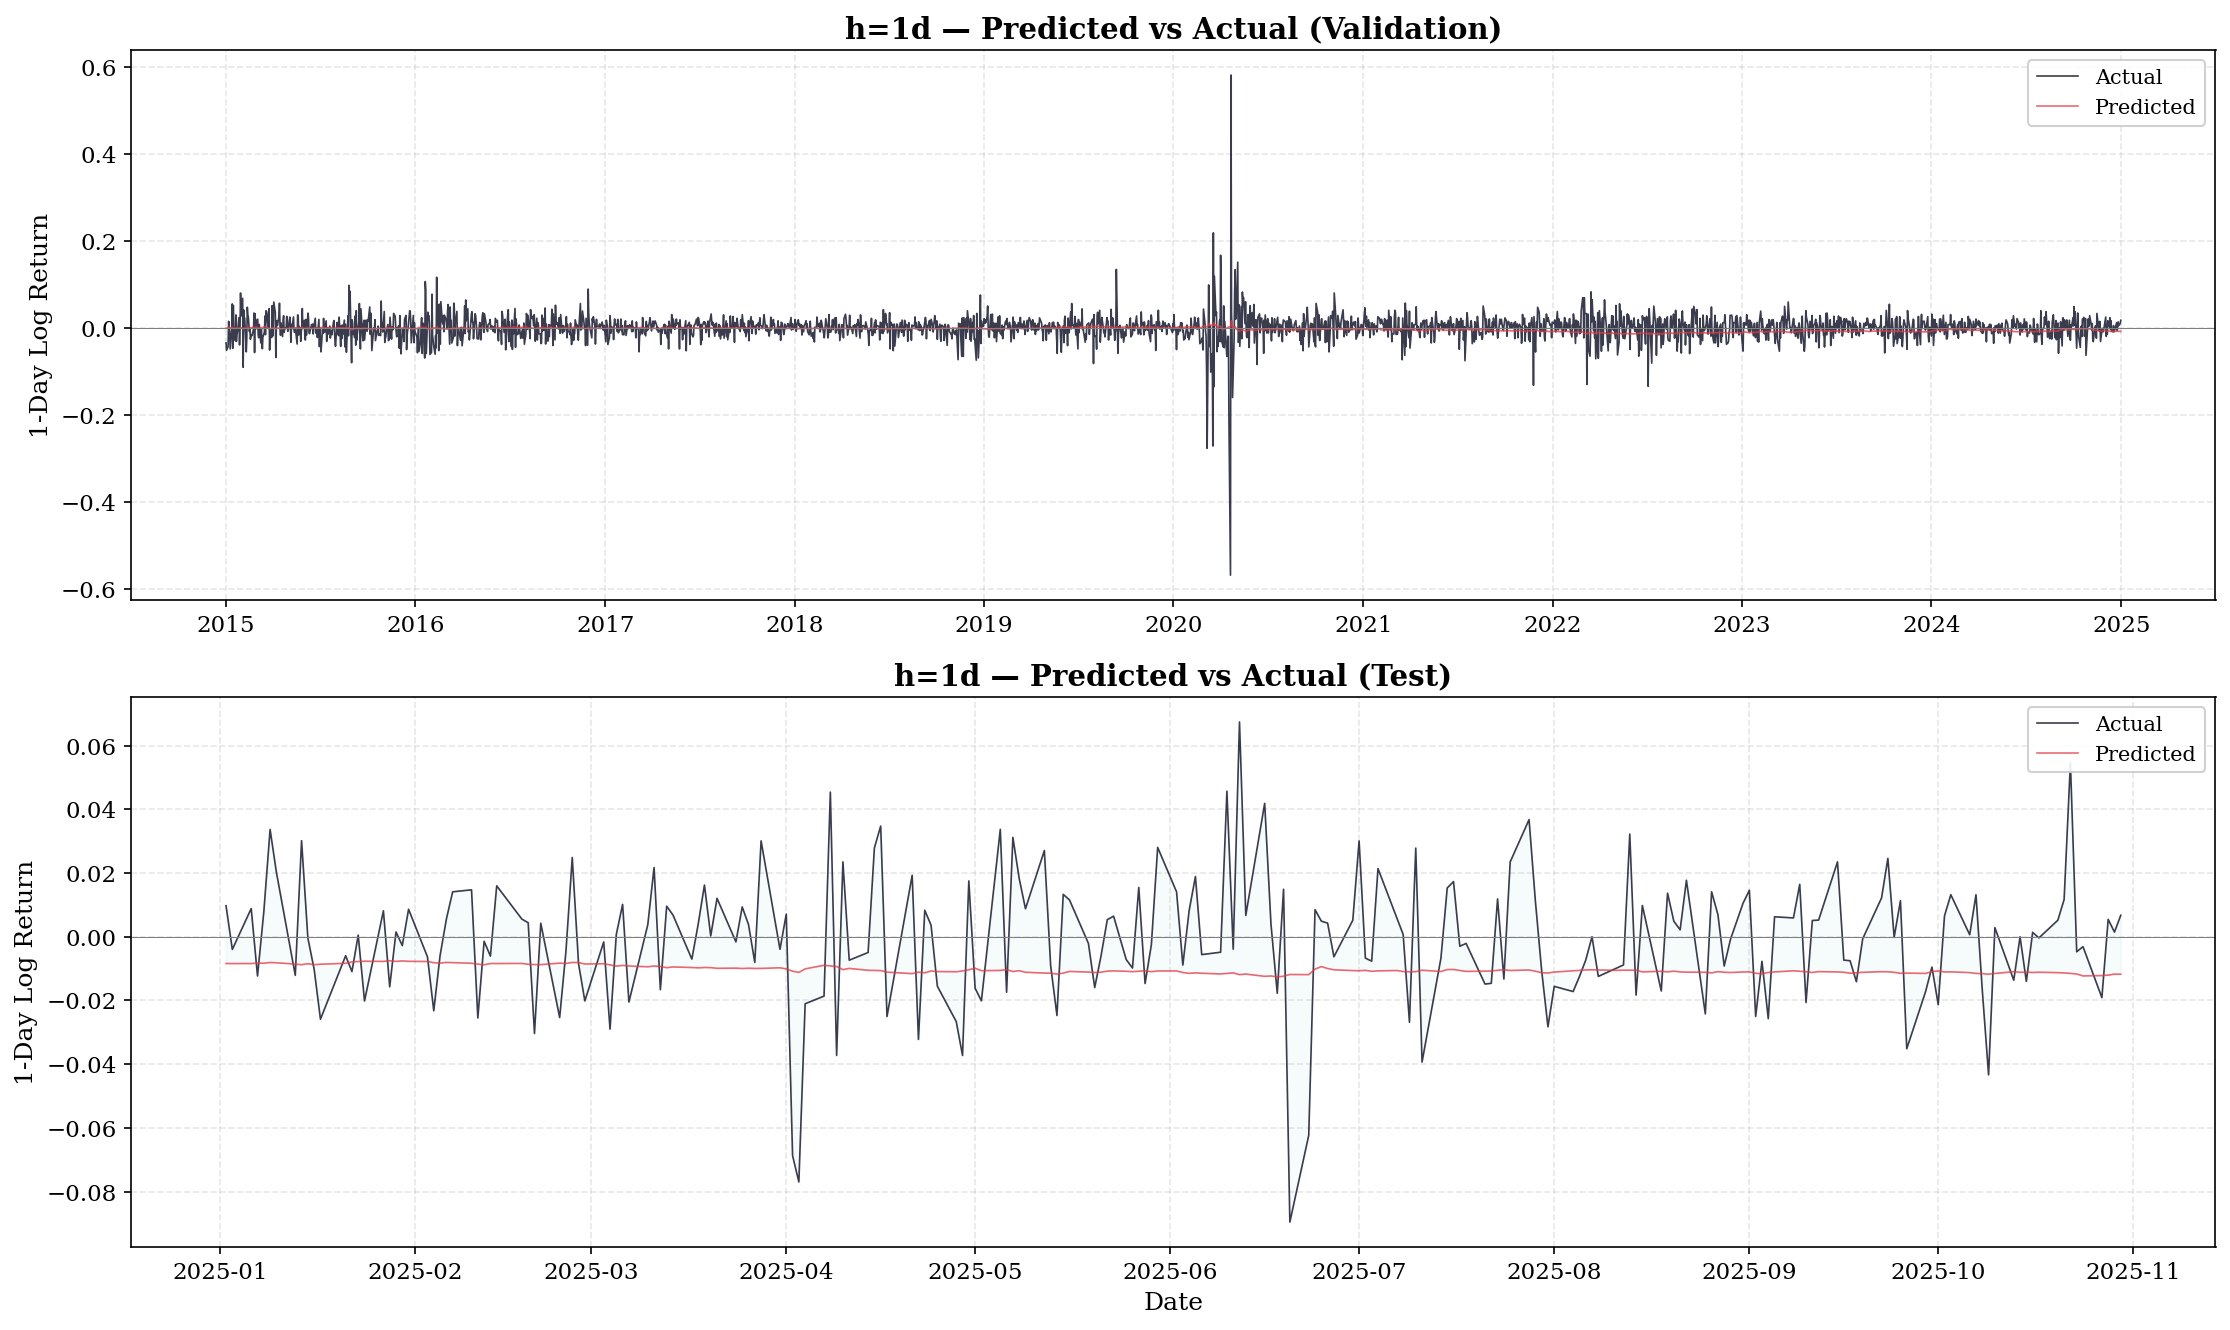

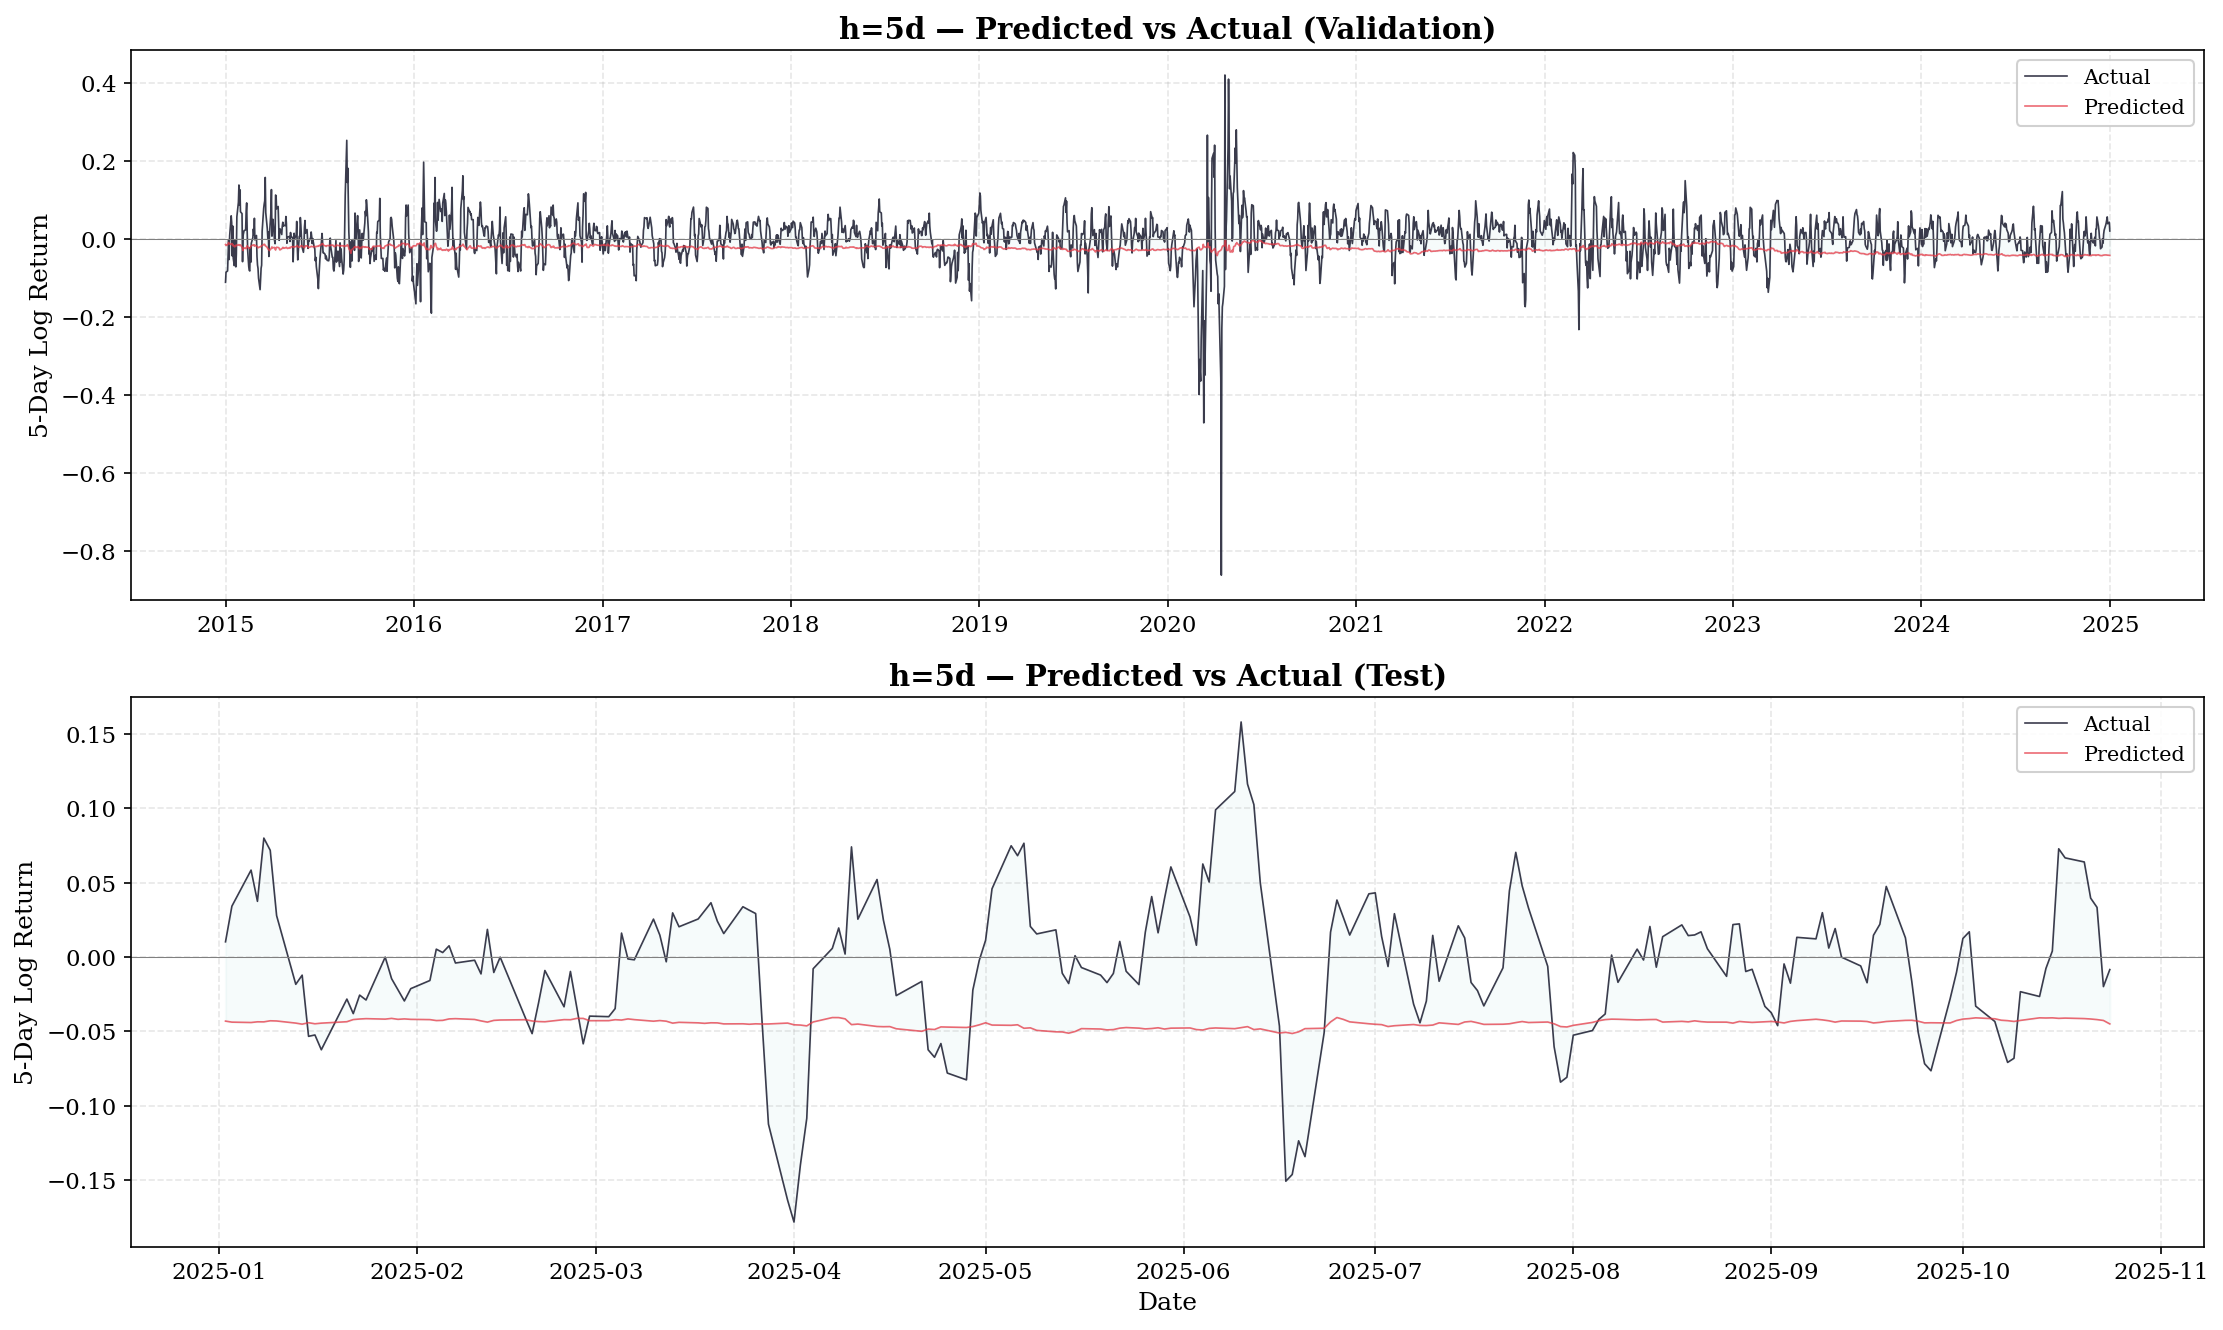

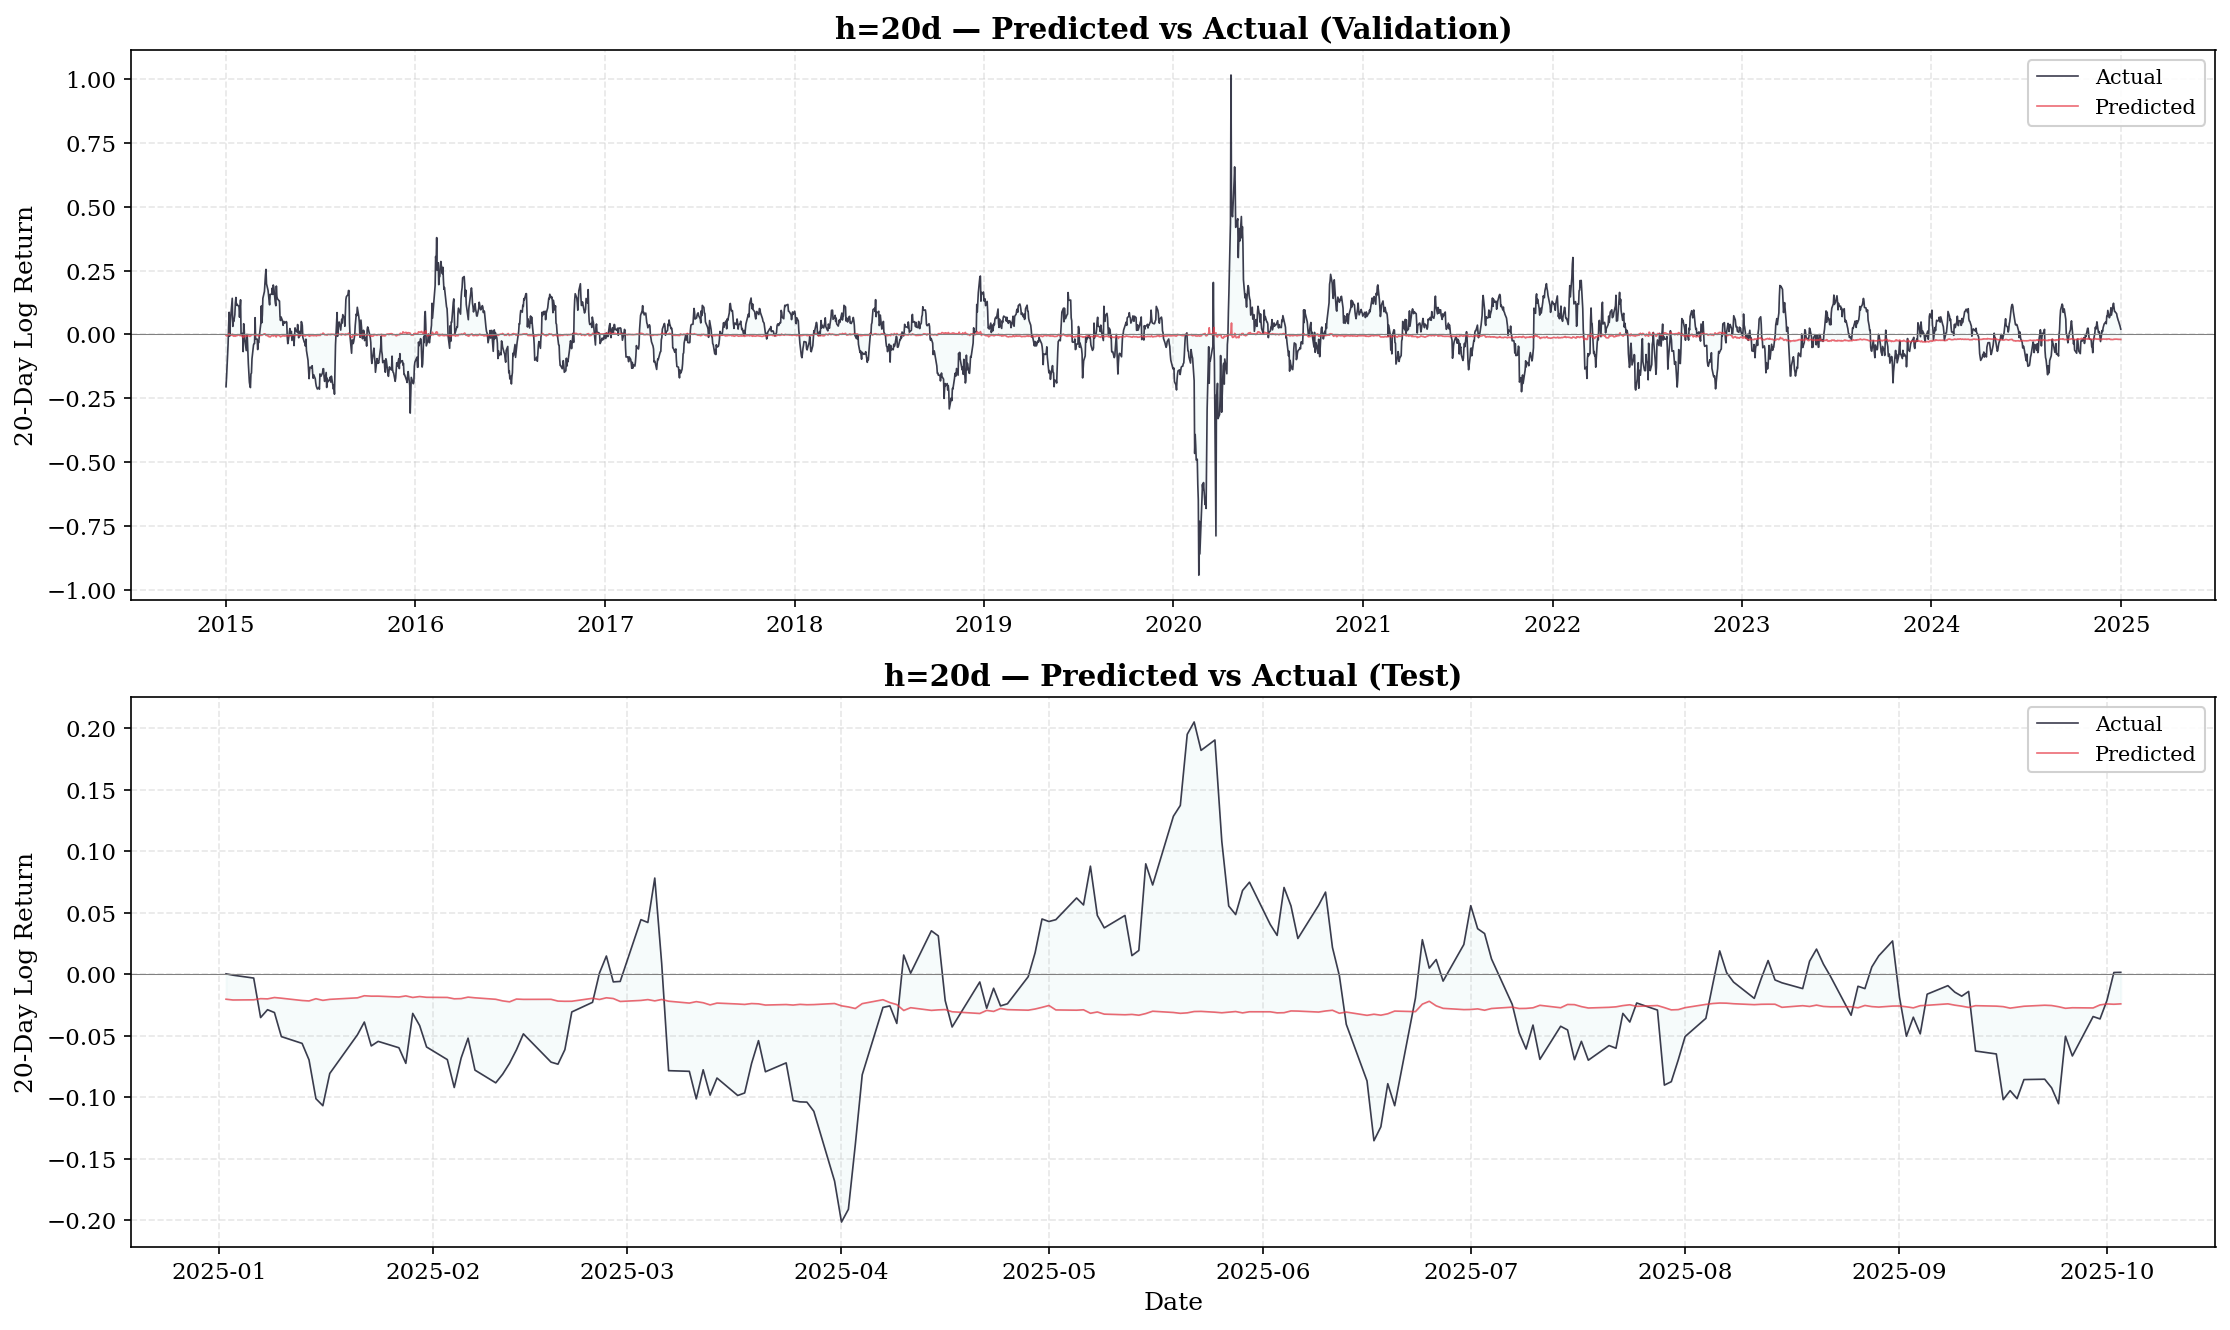

In [15]:
# ============================================================
# Predicted vs Actual — Time Series
# ============================================================
for h in HORIZONS:
    r = results[h]
    fig, axes = plt.subplots(2, 1, figsize=(15, 9))

    for ax, dates, yt, yp, label in [
        (axes[0], r['dva'], r['yva'], r['pred_val'], 'Validation'),
        (axes[1], r['dte'], r['yte'], r['pred_test'], 'Test'),
    ]:
        ax.plot(dates, yt, color=C['actual'], lw=0.8, alpha=0.85, label='Actual')
        ax.plot(dates, yp, color=C['pred'], lw=0.8, alpha=0.75, label='Predicted')
        ax.fill_between(dates, yt, yp, alpha=0.10, color=C['fill'])
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_title(f'h={h}d — Predicted vs Actual ({label})', fontweight='bold')
        ax.set_ylabel(f'{h}-Day Log Return')
        ax.legend(loc='upper right', framealpha=0.9)

    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

## 14. Training & Validation Loss Curves
To visualize convergence behavior, we retrain the best configuration for each horizon while recording per-epoch train and validation RMSE. The vertical dashed line marks the epoch where early stopping would trigger. A large gap between train and val loss indicates overfitting; convergence at similar levels indicates the model is appropriately regularized.

Using device: cuda
Retraining h=1d for loss curves...
Retraining h=5d for loss curves...
Retraining h=20d for loss curves...


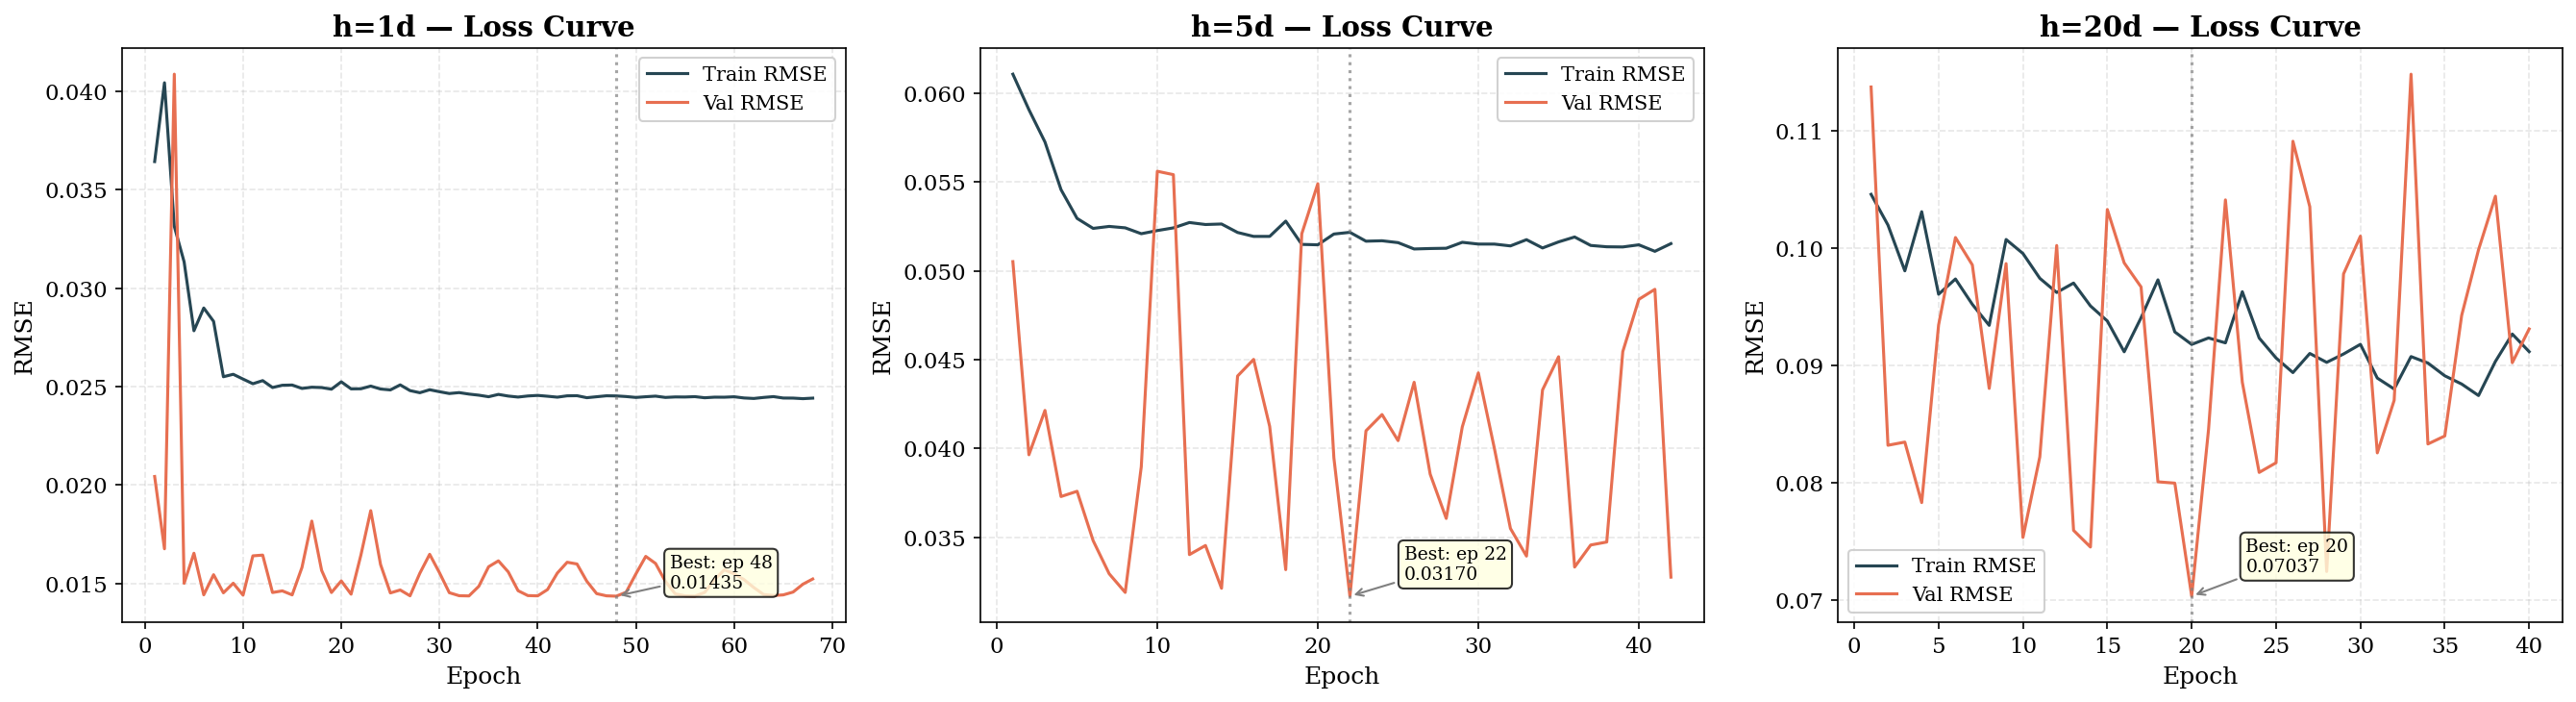

In [16]:
# ============================================================
# Training & Validation Loss Curves
# ============================================================
def retrain_with_loss_tracking(X_train, y_train, best_params,
                               epochs=200, patience=20, batch_size=128):
    """Retrain the best LSTM config while recording per-epoch losses.

    Uses the same 90/10 split as the final training in LSTMForecastModel.fit().
    Returns lists of per-epoch train and validation RMSE.
    """
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    n = len(X_train)
    split = int(n * 0.9)
    Xtr_f, Xva_f = X_train[:split], X_train[split:]
    ytr_f, yva_f = y_train[:split], y_train[split:]

    # Scale (fit on train portion only)
    _, T, F = Xtr_f.shape
    sc = StandardScaler()
    sc.fit(Xtr_f.reshape(-1, F))
    Xtr_s = sc.transform(Xtr_f.reshape(-1, F)).reshape(len(Xtr_f), T, F).astype(np.float32)
    Xva_s = sc.transform(Xva_f.reshape(-1, F)).reshape(len(Xva_f), T, F).astype(np.float32)

    net = LSTMNet(F, best_params['hidden_size'],
                  best_params['num_layers'], best_params['dropout']).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=best_params['lr'], weight_decay=1e-5)
    crit = nn.MSELoss()

    tr_dl = DataLoader(TensorDataset(torch.tensor(Xtr_s), torch.tensor(ytr_f)),
                       batch_size=batch_size, shuffle=False)
    va_dl = DataLoader(TensorDataset(torch.tensor(Xva_s), torch.tensor(yva_f)),
                       batch_size=batch_size*2, shuffle=False)

    train_losses, val_losses = [], []
    best_val, wait = np.inf, 0

    for ep in range(1, epochs + 1):
        net.train()
        ep_loss = 0.0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(net(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item() * len(xb)
        train_losses.append(np.sqrt(ep_loss / len(Xtr_s)))

        net.eval()
        vp = []
        with torch.no_grad():
            for xb, _ in va_dl:
                vp.append(net(xb.to(device)).cpu().numpy())
        vl = float(np.sqrt(np.mean((yva_f - np.concatenate(vp))**2)))
        val_losses.append(vl)

        if vl < best_val:
            best_val, wait = vl, 0
        else:
            wait += 1
            if wait >= patience: break

    return train_losses, val_losses


# --- Generate loss curves for each horizon ---
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(6*len(HORIZONS), 5))
if len(HORIZONS) == 1: axes = [axes]

print(f'Using device: {"cuda" if torch.cuda.is_available() else "cpu"}')

for ax, h in zip(axes, HORIZONS):
    r = results[h]
    bp = r['model'].best_params_
    print(f'Retraining h={h}d for loss curves...')
    tl, vl = retrain_with_loss_tracking(r['Xtr'], r['ytr'], bp)

    eps = range(1, len(tl) + 1)
    ax.plot(eps, tl, color=C['h1'], lw=1.5, label='Train RMSE')
    ax.plot(eps, vl, color=C['neg'], lw=1.5, label='Val RMSE')

    # Mark best epoch
    best_ep = np.argmin(vl) + 1
    best_v = min(vl)
    ax.axvline(best_ep, color='gray', ls=':', alpha=0.7)
    ax.annotate(f'Best: ep {best_ep}\n{best_v:.5f}',
                xy=(best_ep, best_v), fontsize=9,
                xytext=(best_ep + len(tl)*0.08, best_v*1.03),
                arrowprops=dict(arrowstyle='->', color='gray'),
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

    ax.set_title(f'h={h}d — Loss Curve', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE')
    ax.legend(framealpha=0.9)

plt.tight_layout()
plt.show()

## 15. Scatter Plot — Predicted vs Actual
If the model has predictive power, points cluster along the 45° line (perfect forecast). The regression line slope and correlation coefficient quantify this: a slope near 0 and correlation near 0 confirm the model is not capturing the actual return signal.

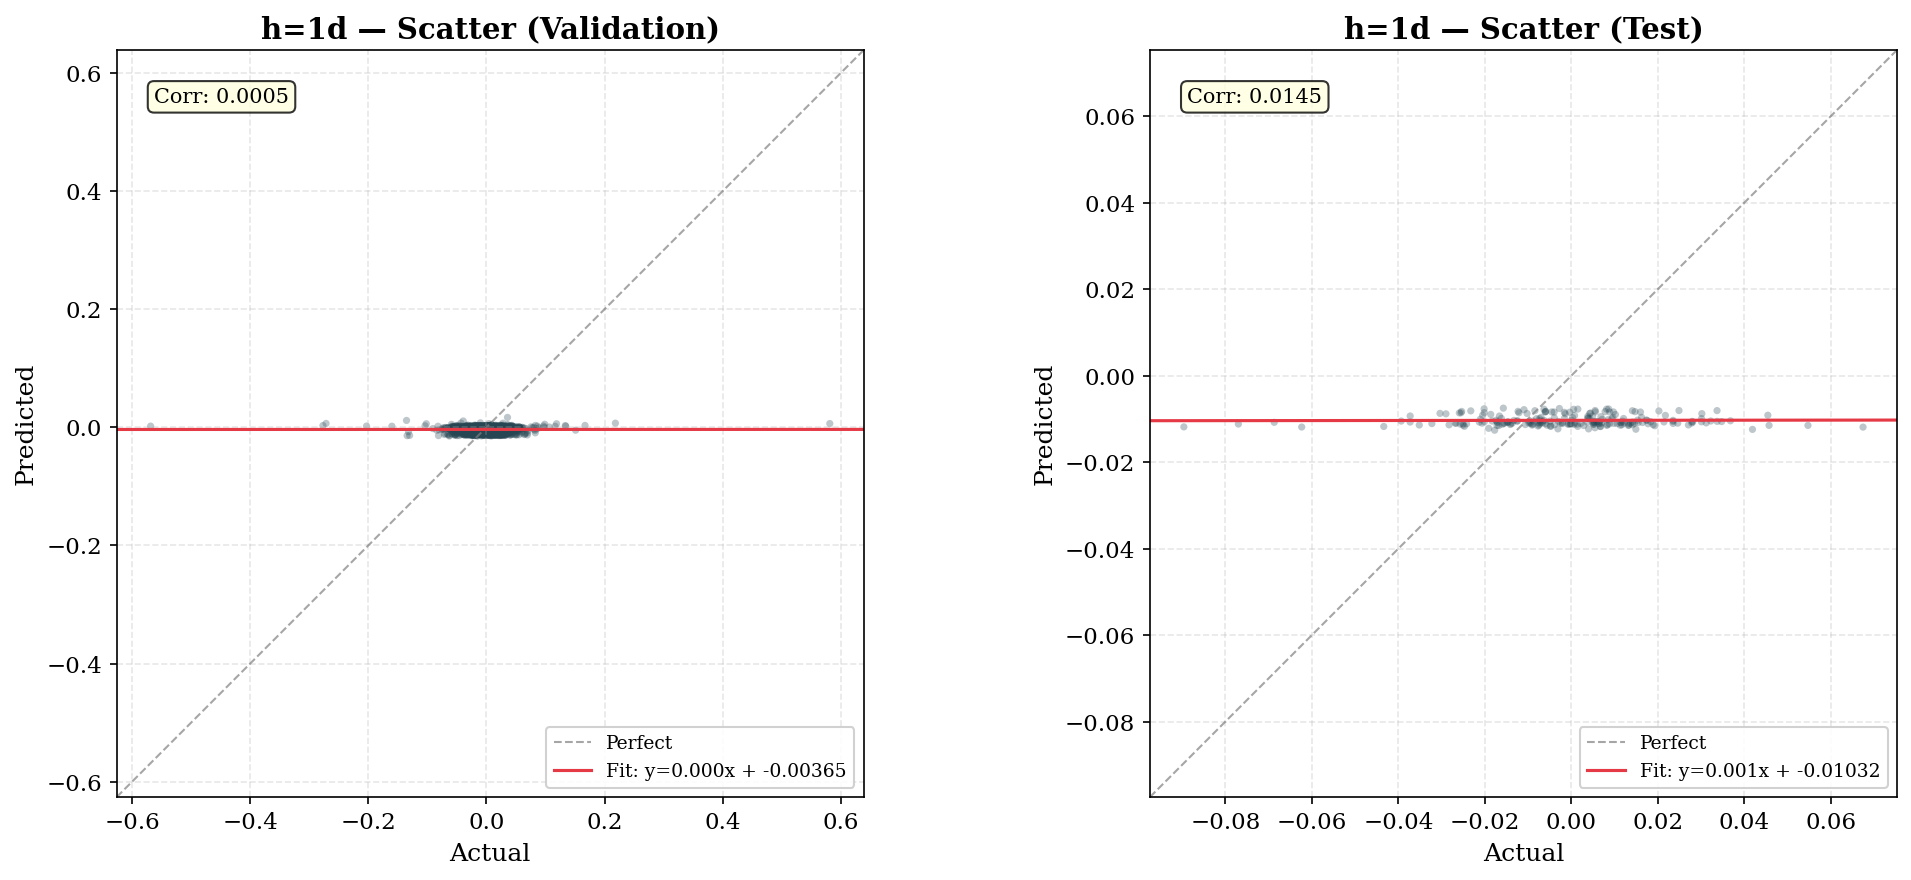

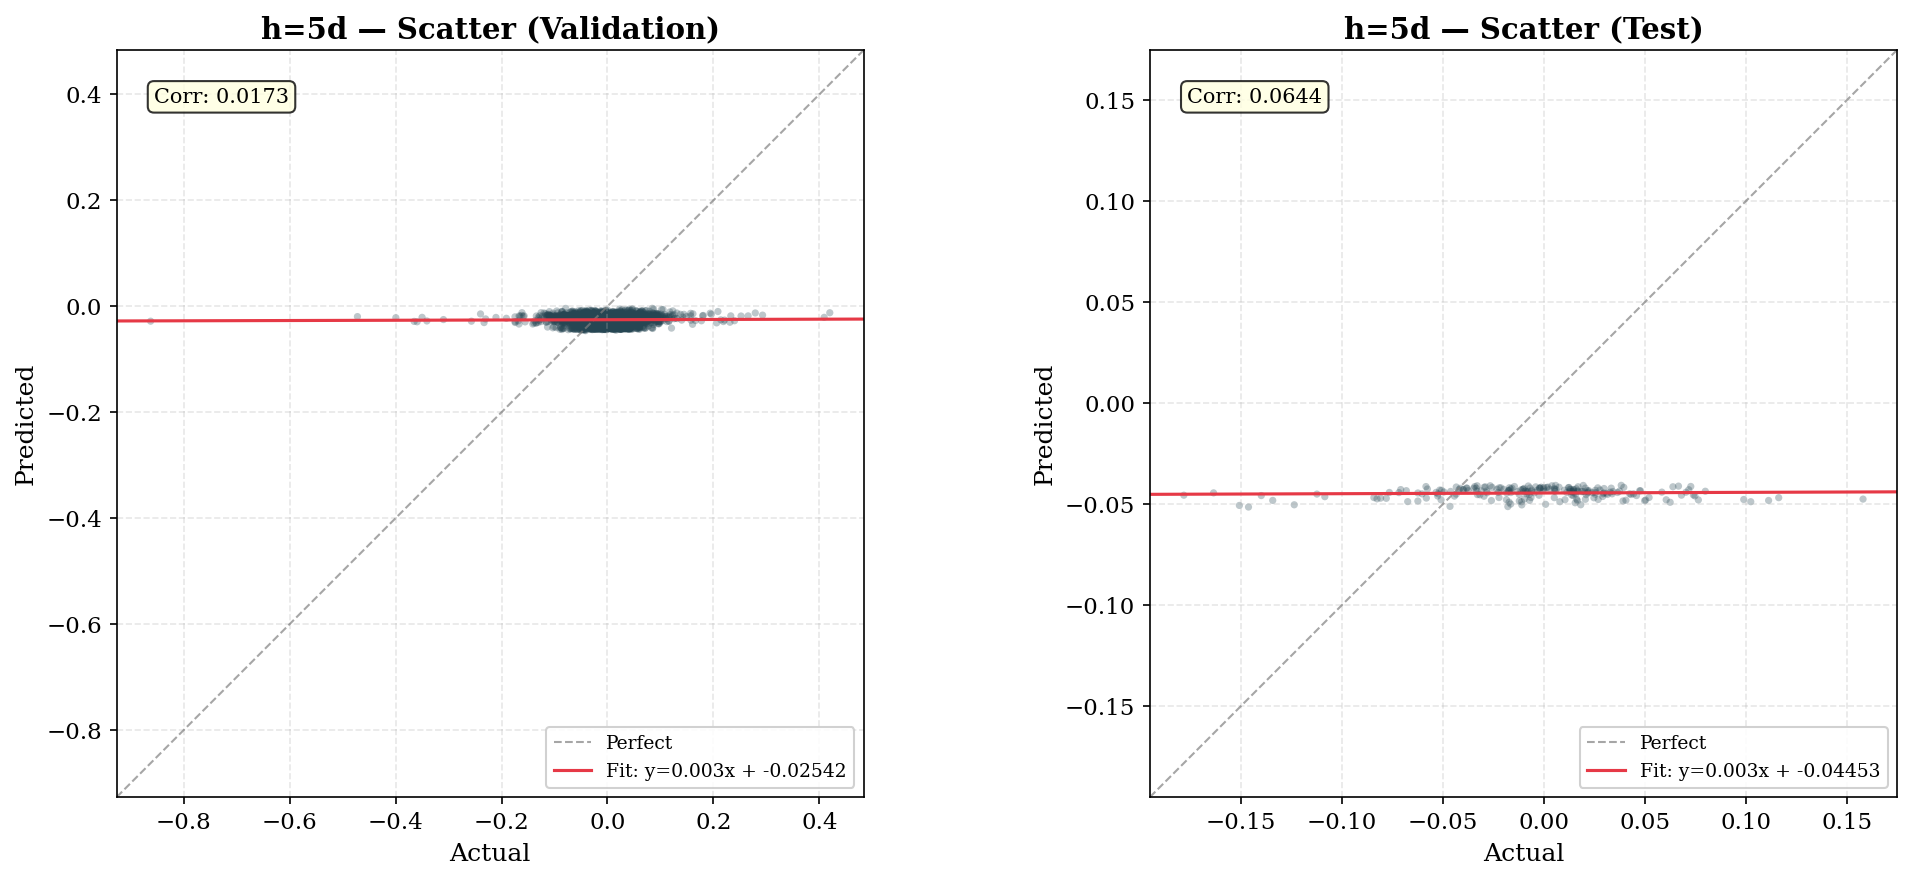

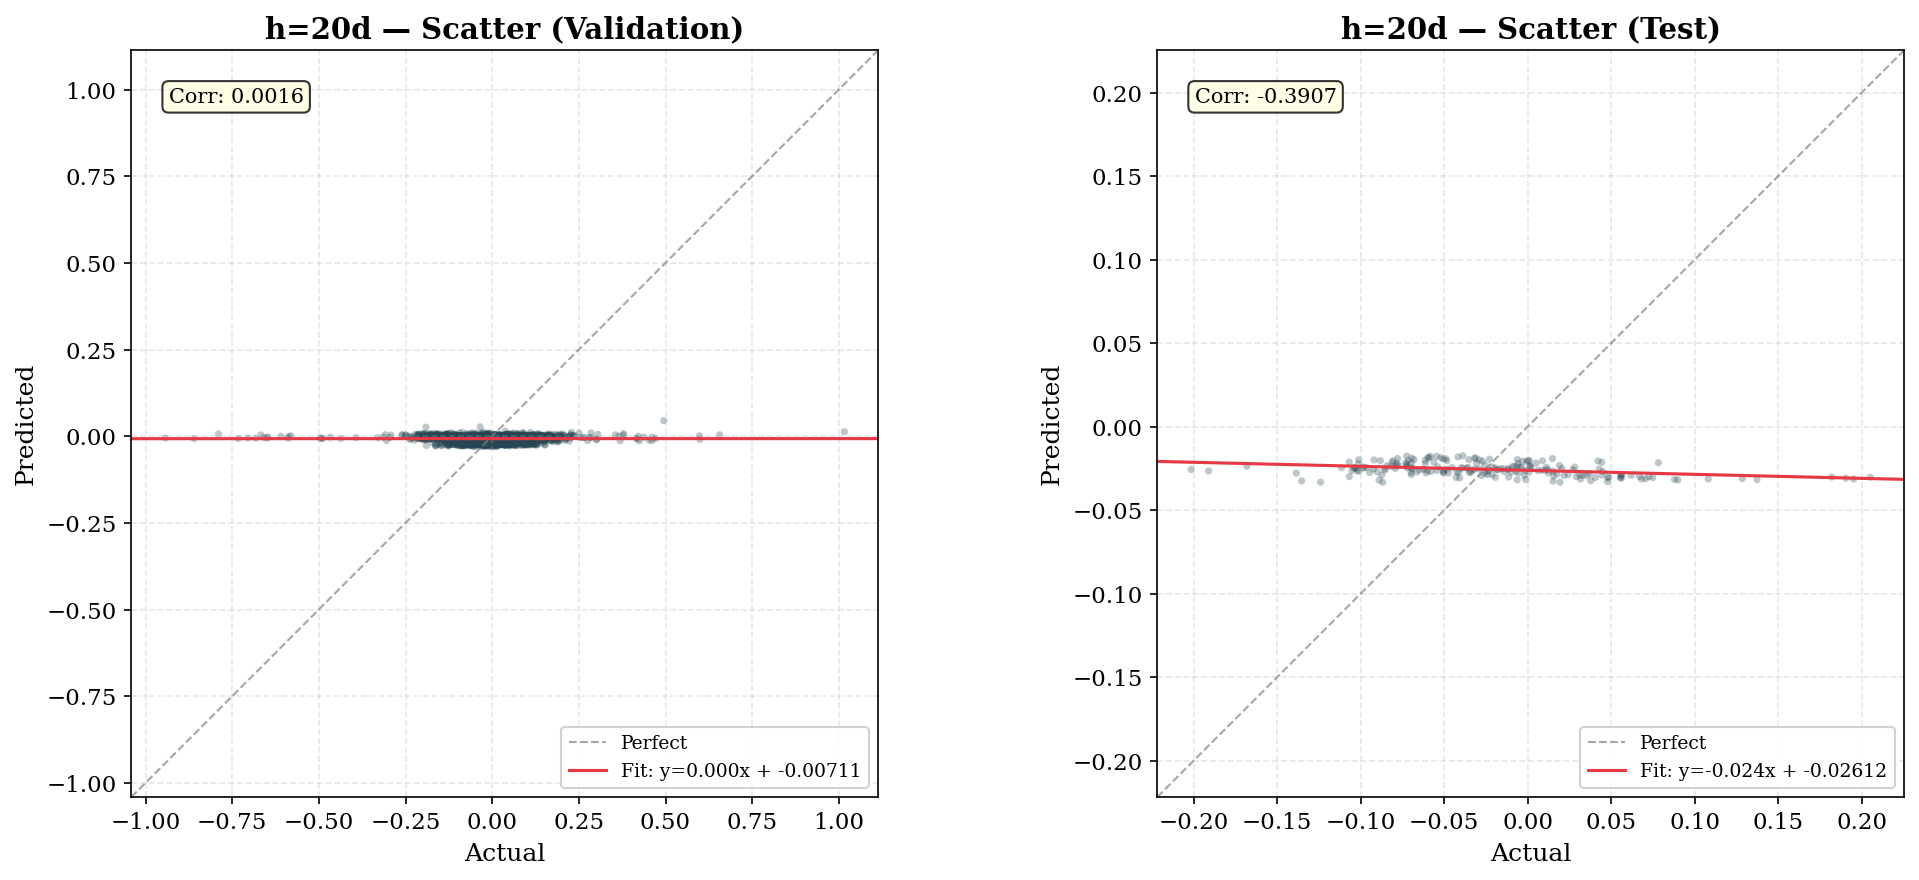

In [17]:
# ============================================================
# Scatter — Predicted vs Actual
# ============================================================
for h in HORIZONS:
    r = results[h]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, yt, yp, label in [
        (axes[0], r['yva'], r['pred_val'], 'Validation'),
        (axes[1], r['yte'], r['pred_test'], 'Test'),
    ]:
        ax.scatter(yt, yp, alpha=0.3, s=12, color=C['h1'], edgecolors='none')

        # Axis limits with margin
        lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
        m = (lims[1] - lims[0]) * 0.05
        lims = [lims[0]-m, lims[1]+m]

        # Perfect forecast line (45°)
        ax.plot(lims, lims, '--', color='gray', lw=1, alpha=0.7, label='Perfect')

        # OLS regression line
        z = np.polyfit(yt, yp, 1)
        xl = np.linspace(lims[0], lims[1], 100)
        ax.plot(xl, np.poly1d(z)(xl), color=C['pred'], lw=1.5,
                label=f'Fit: y={z[0]:.3f}x + {z[1]:.5f}')

        # Correlation annotation
        corr = np.corrcoef(yt, yp)[0, 1]
        ax.text(0.05, 0.95, f'Corr: {corr:.4f}', transform=ax.transAxes,
                fontsize=10, va='top',
                bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.set_title(f'h={h}d — Scatter ({label})', fontweight='bold')
        ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
        ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

## 16. Residual Analysis — Histogram & Q-Q Plot
Examine the distribution of forecast errors (actual − predicted). For a well-specified model, residuals should be centered at zero with no heavy tails. The Q-Q plot compares residual quantiles against a normal distribution — deviations at the tails (heavy tails) indicate the model underestimates extreme moves, which is expected for oil given its kurtosis of 60+.

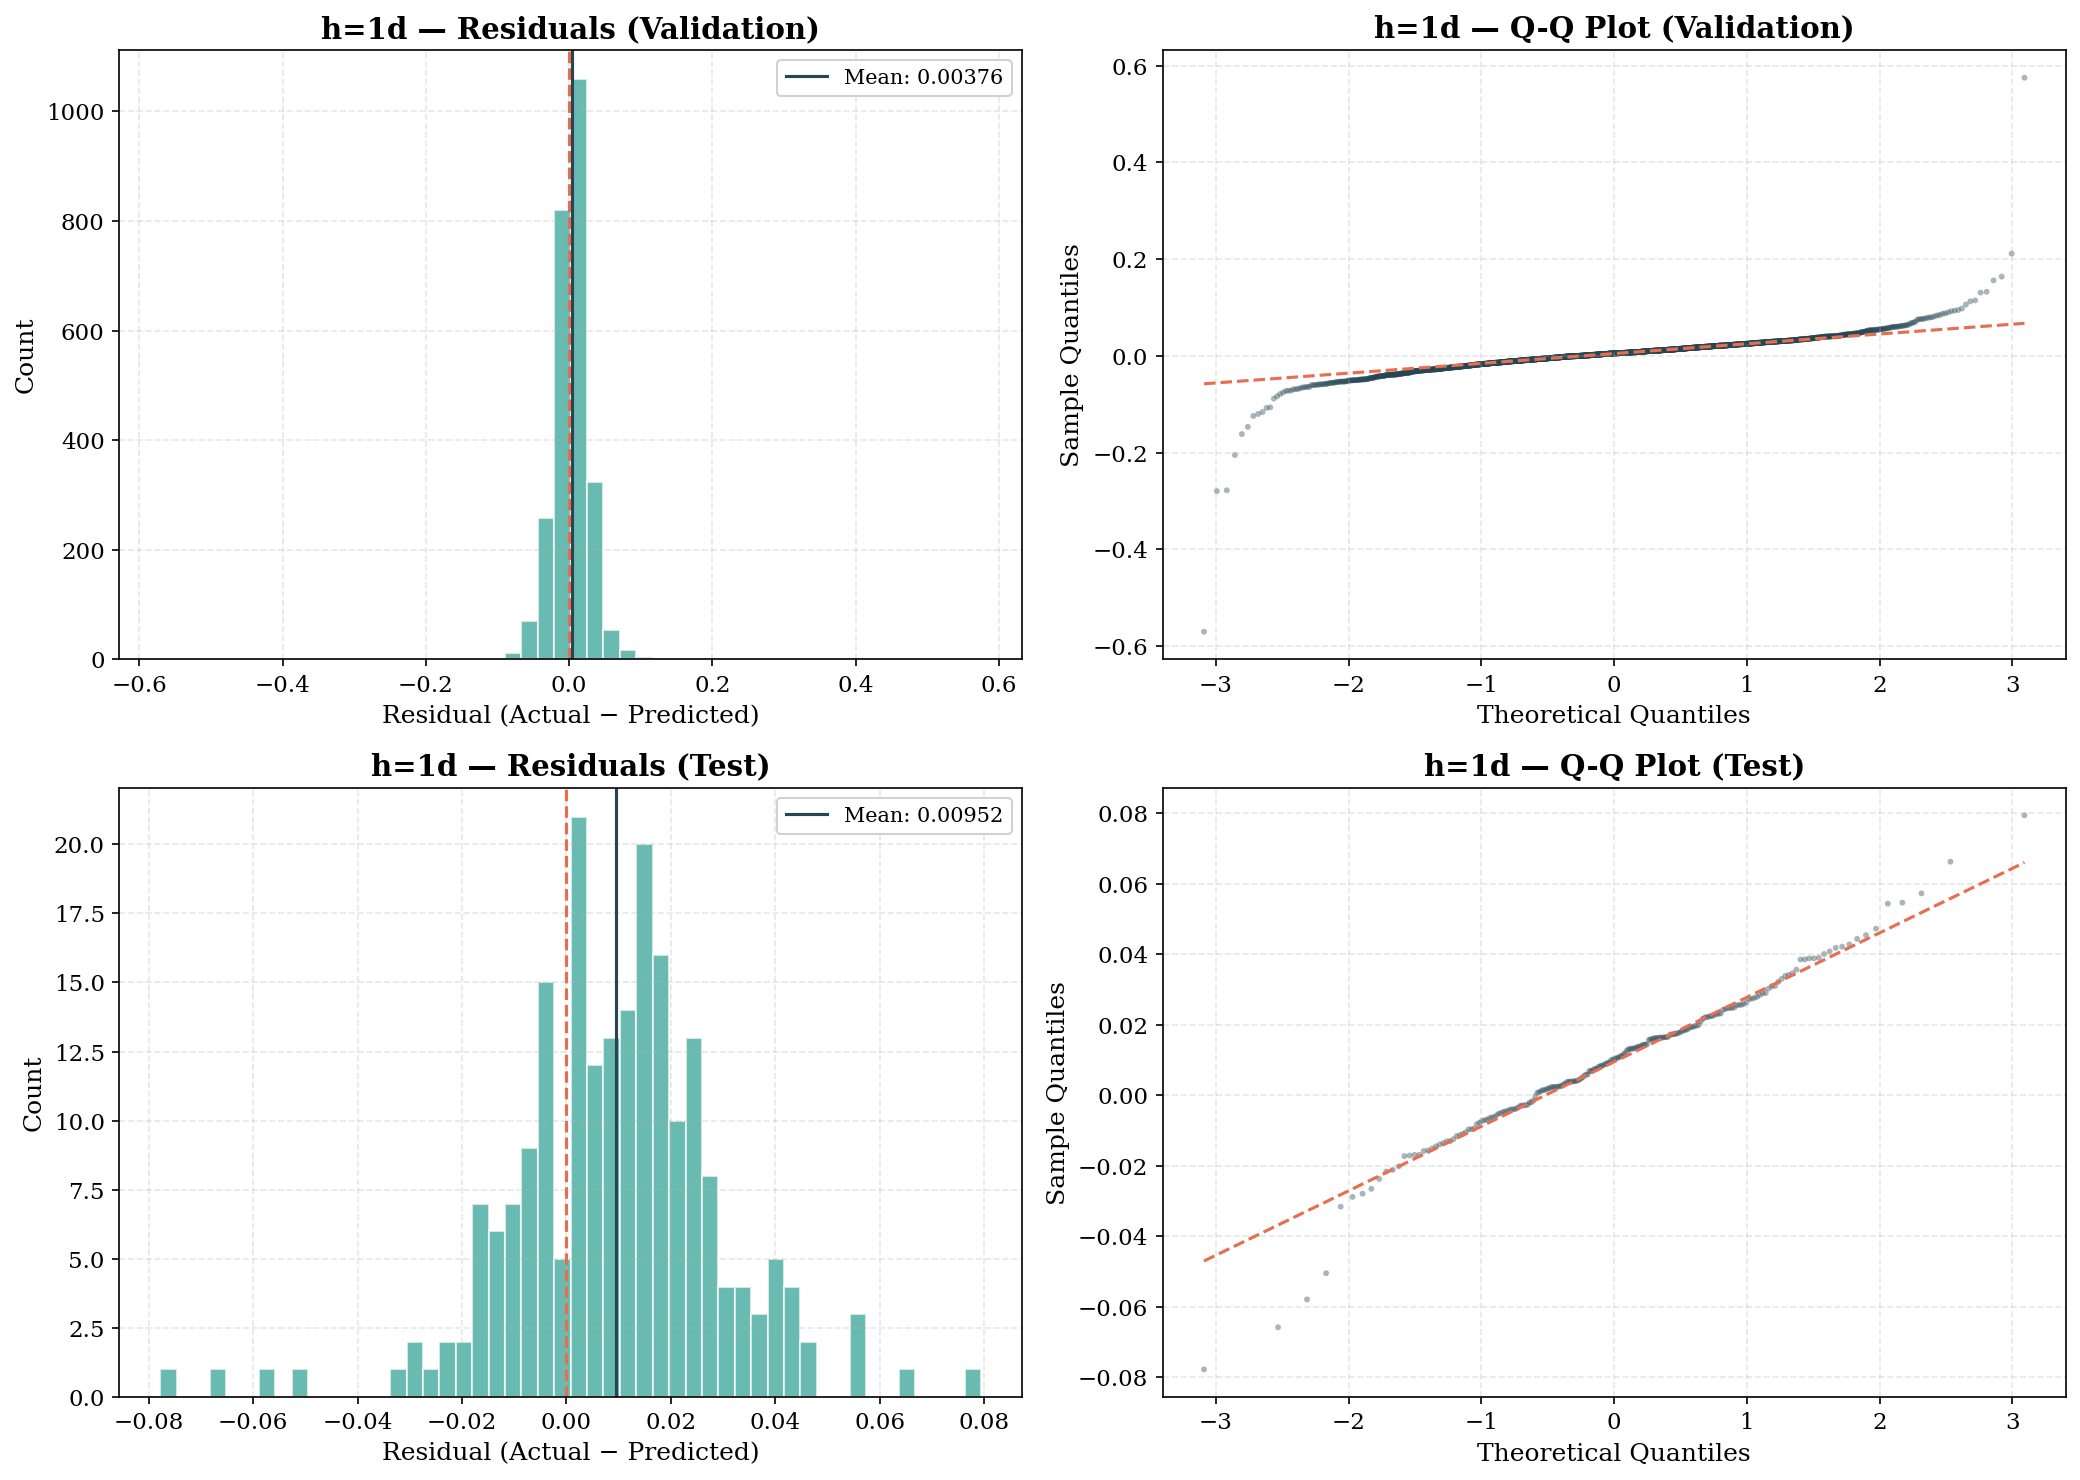

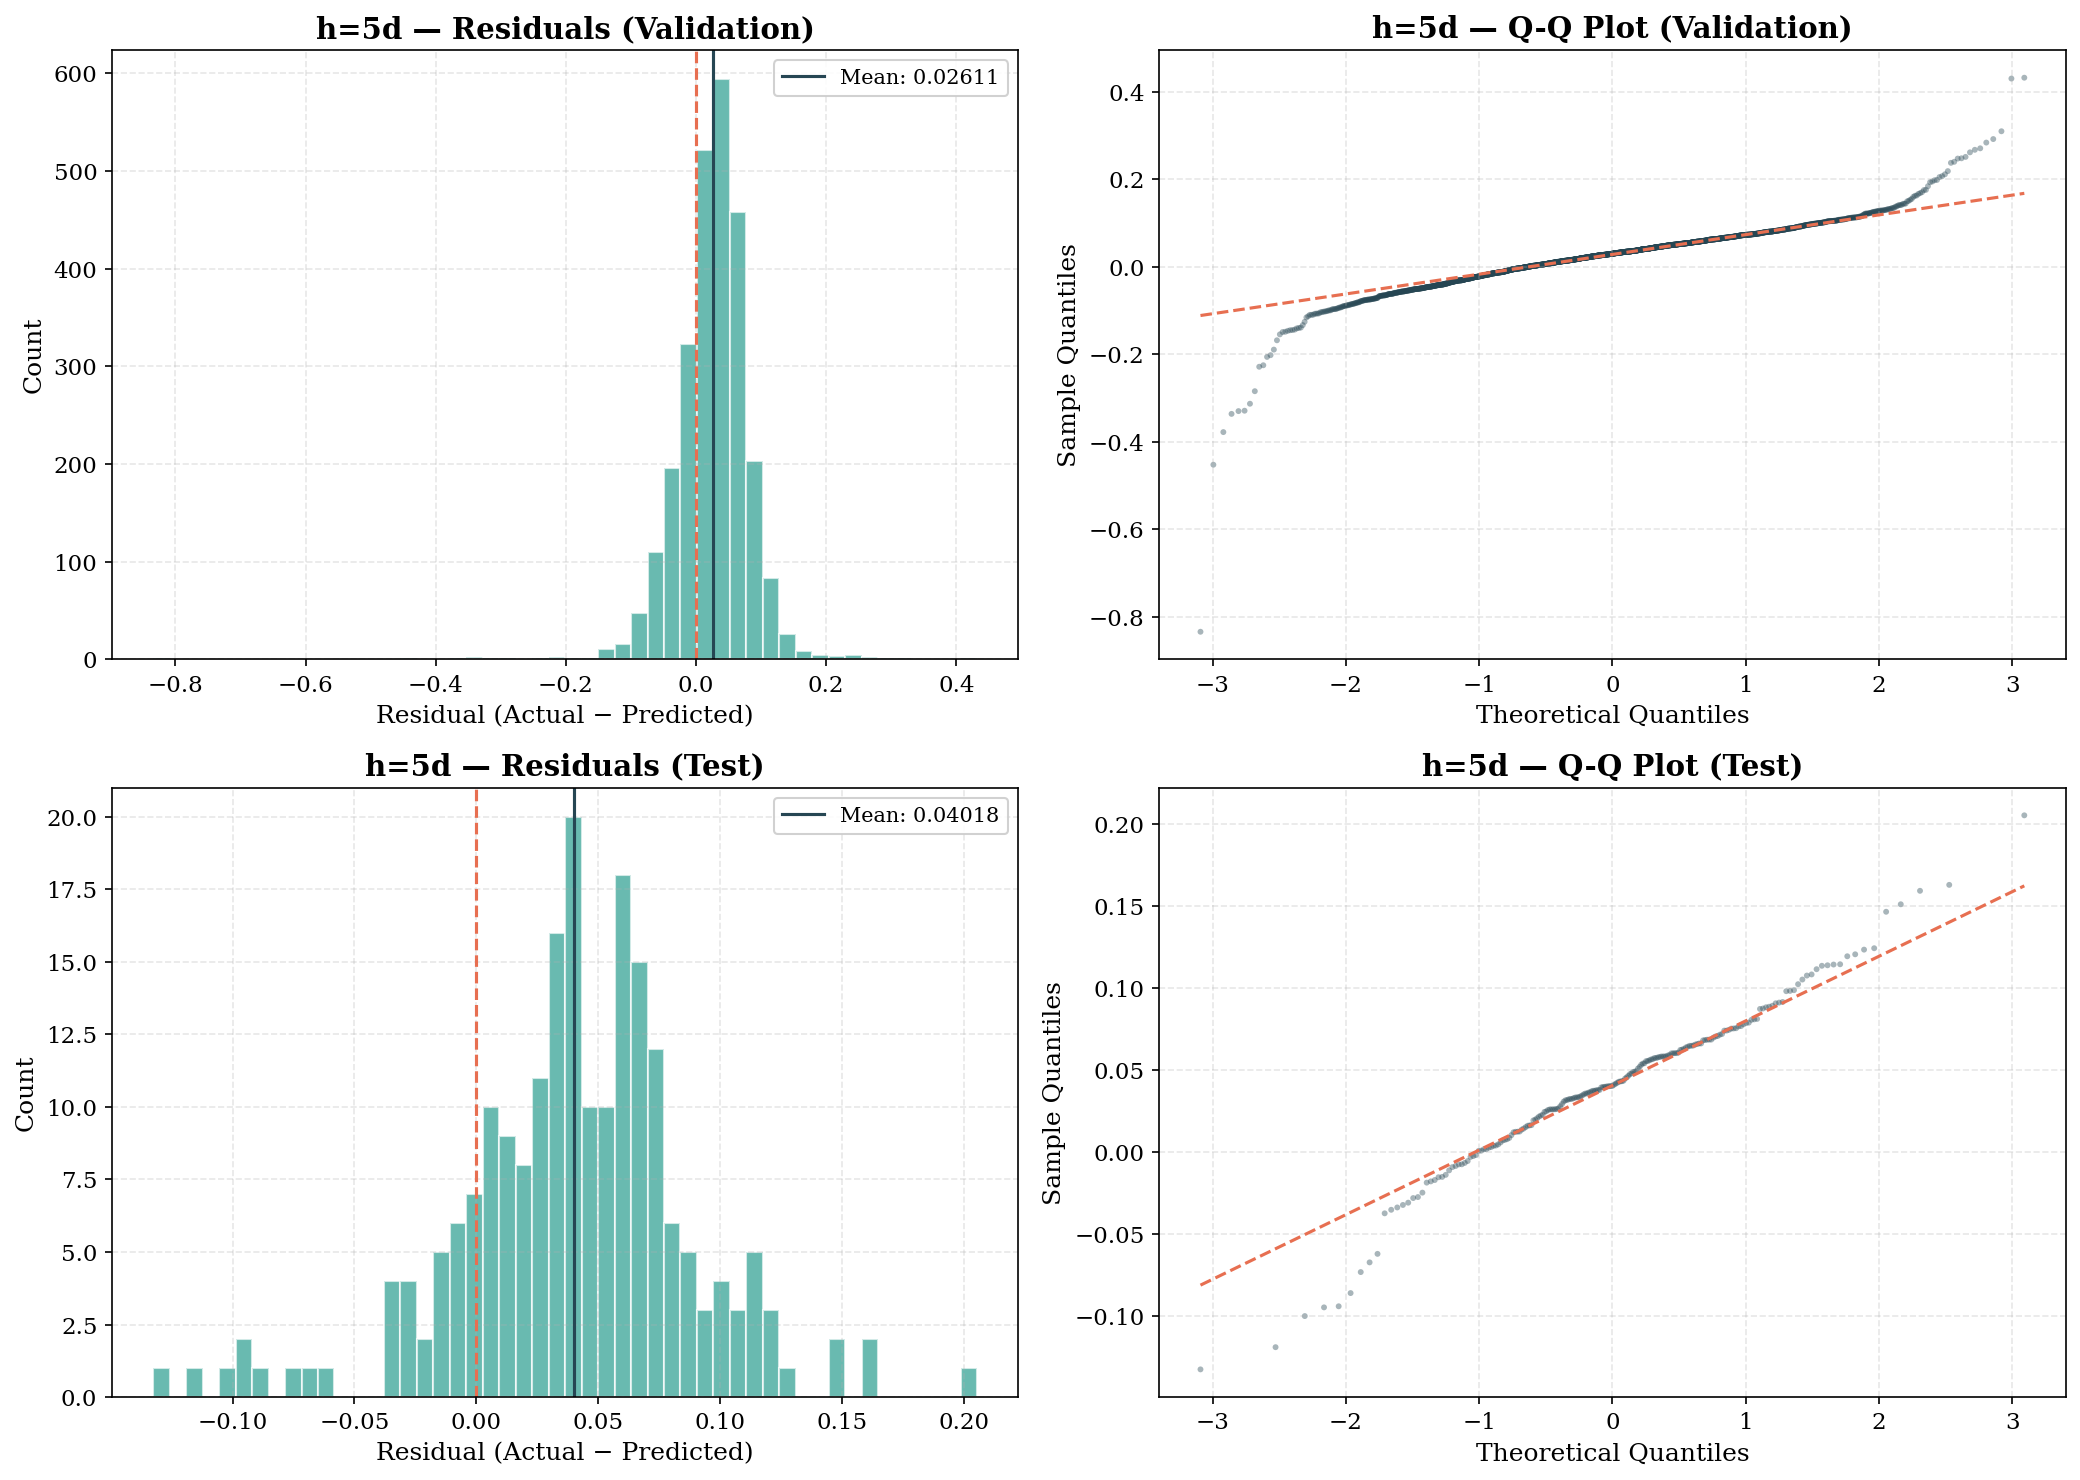

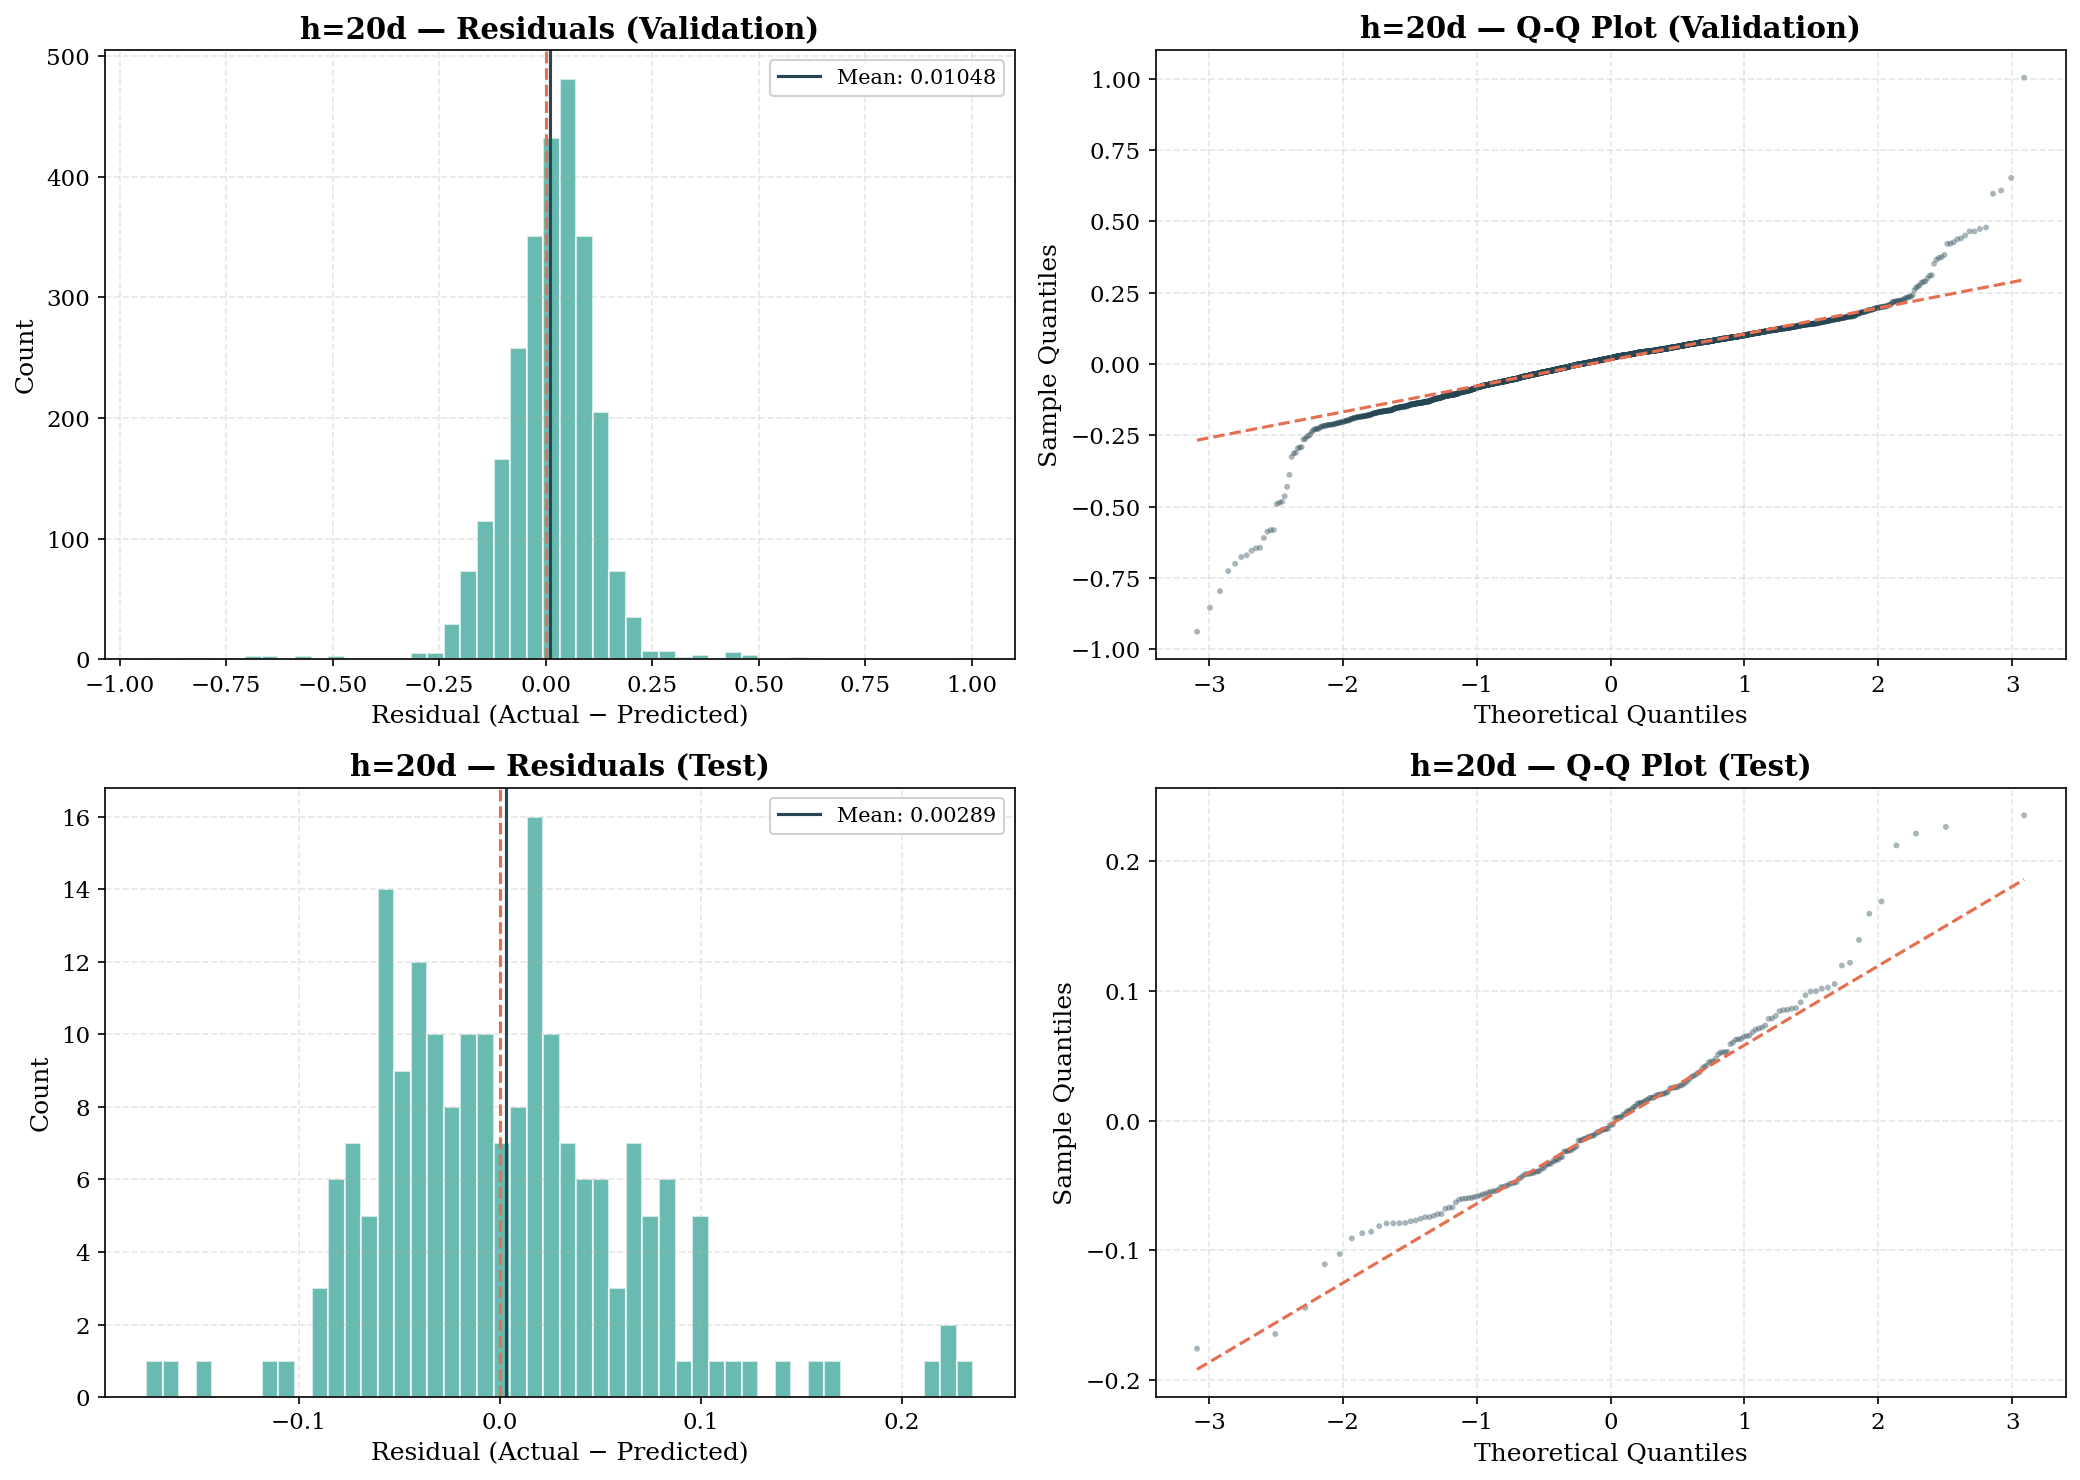

In [18]:
# ============================================================
# Residual Analysis — Histogram + Q-Q Plot
# ============================================================
for h in HORIZONS:
    r = results[h]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for row, (yt, yp, label) in enumerate([
        (r['yva'], r['pred_val'], 'Validation'),
        (r['yte'], r['pred_test'], 'Test'),
    ]):
        res = yt - yp  # residuals

        # Histogram
        ax = axes[row, 0]
        ax.hist(res, bins=50, color=C['pos'], alpha=0.7, edgecolor='white', lw=0.3)
        ax.axvline(0, color=C['neg'], lw=1.5, ls='--')
        ax.axvline(res.mean(), color=C['h1'], lw=1.5, label=f'Mean: {res.mean():.5f}')
        ax.set_title(f'h={h}d — Residuals ({label})', fontweight='bold')
        ax.set_xlabel('Residual (Actual − Predicted)')
        ax.set_ylabel('Count')
        ax.legend(framealpha=0.9)

        # Q-Q Plot
        ax2 = axes[row, 1]
        sr = np.sort(res)
        n = len(sr)
        theo = stats.norm.ppf(np.linspace(0.001, 0.999, n))
        ax2.scatter(theo, sr, alpha=0.4, s=8, color=C['h1'], edgecolors='none')
        # Reference line through 25th/75th percentiles
        q25, q75 = np.percentile(sr, [25, 75])
        t25, t75 = stats.norm.ppf(0.25), stats.norm.ppf(0.75)
        sl = (q75-q25)/(t75-t25)
        ic = q25 - sl*t25
        rx = np.array([theo.min(), theo.max()])
        ax2.plot(rx, sl*rx+ic, '--', color=C['neg'], lw=1.5)
        ax2.set_title(f'h={h}d — Q-Q Plot ({label})', fontweight='bold')
        ax2.set_xlabel('Theoretical Quantiles')
        ax2.set_ylabel('Sample Quantiles')

    plt.tight_layout()
    plt.show()

## 17. Cumulative Returns — Buy & Hold vs LSTM Strategy
A practical test: if the LSTM's directional predictions had been used to trade, would it have made money? We compare three strategies:
- **Buy & Hold**: Always long oil — cumulative sum of actual returns
- **LSTM Long-Only**: Go long when model predicts positive return, flat otherwise
- **LSTM Long/Short**: Go long when positive, short when negative

If the LSTM has no directional skill (~50% accuracy), both strategies will underperform buy & hold due to missed opportunities and transaction costs (not modeled here).

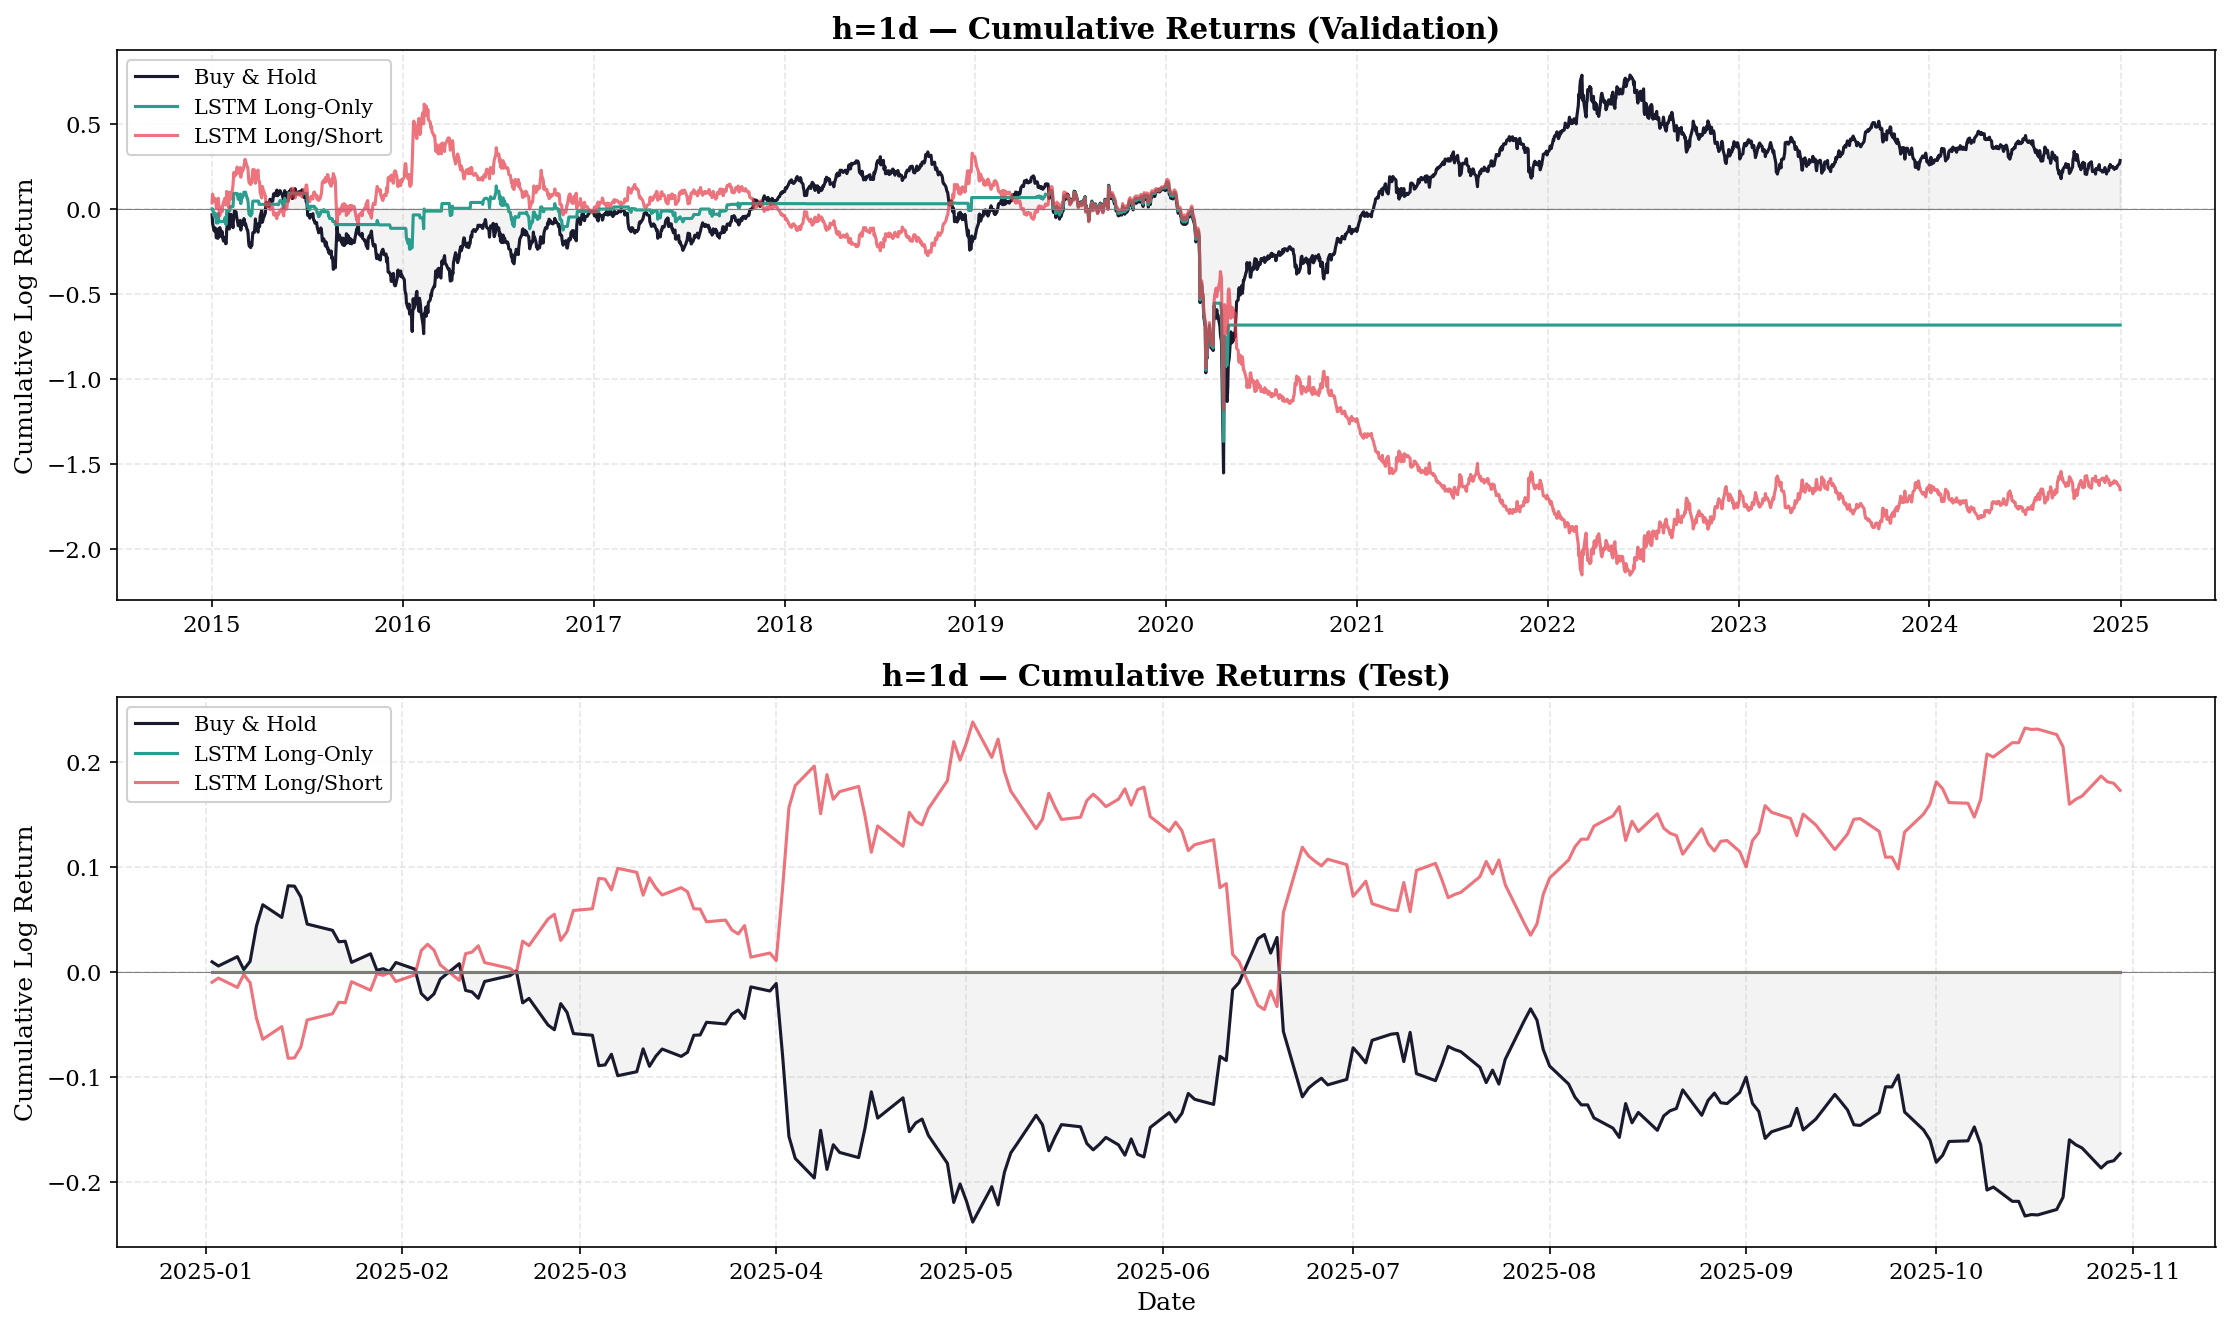

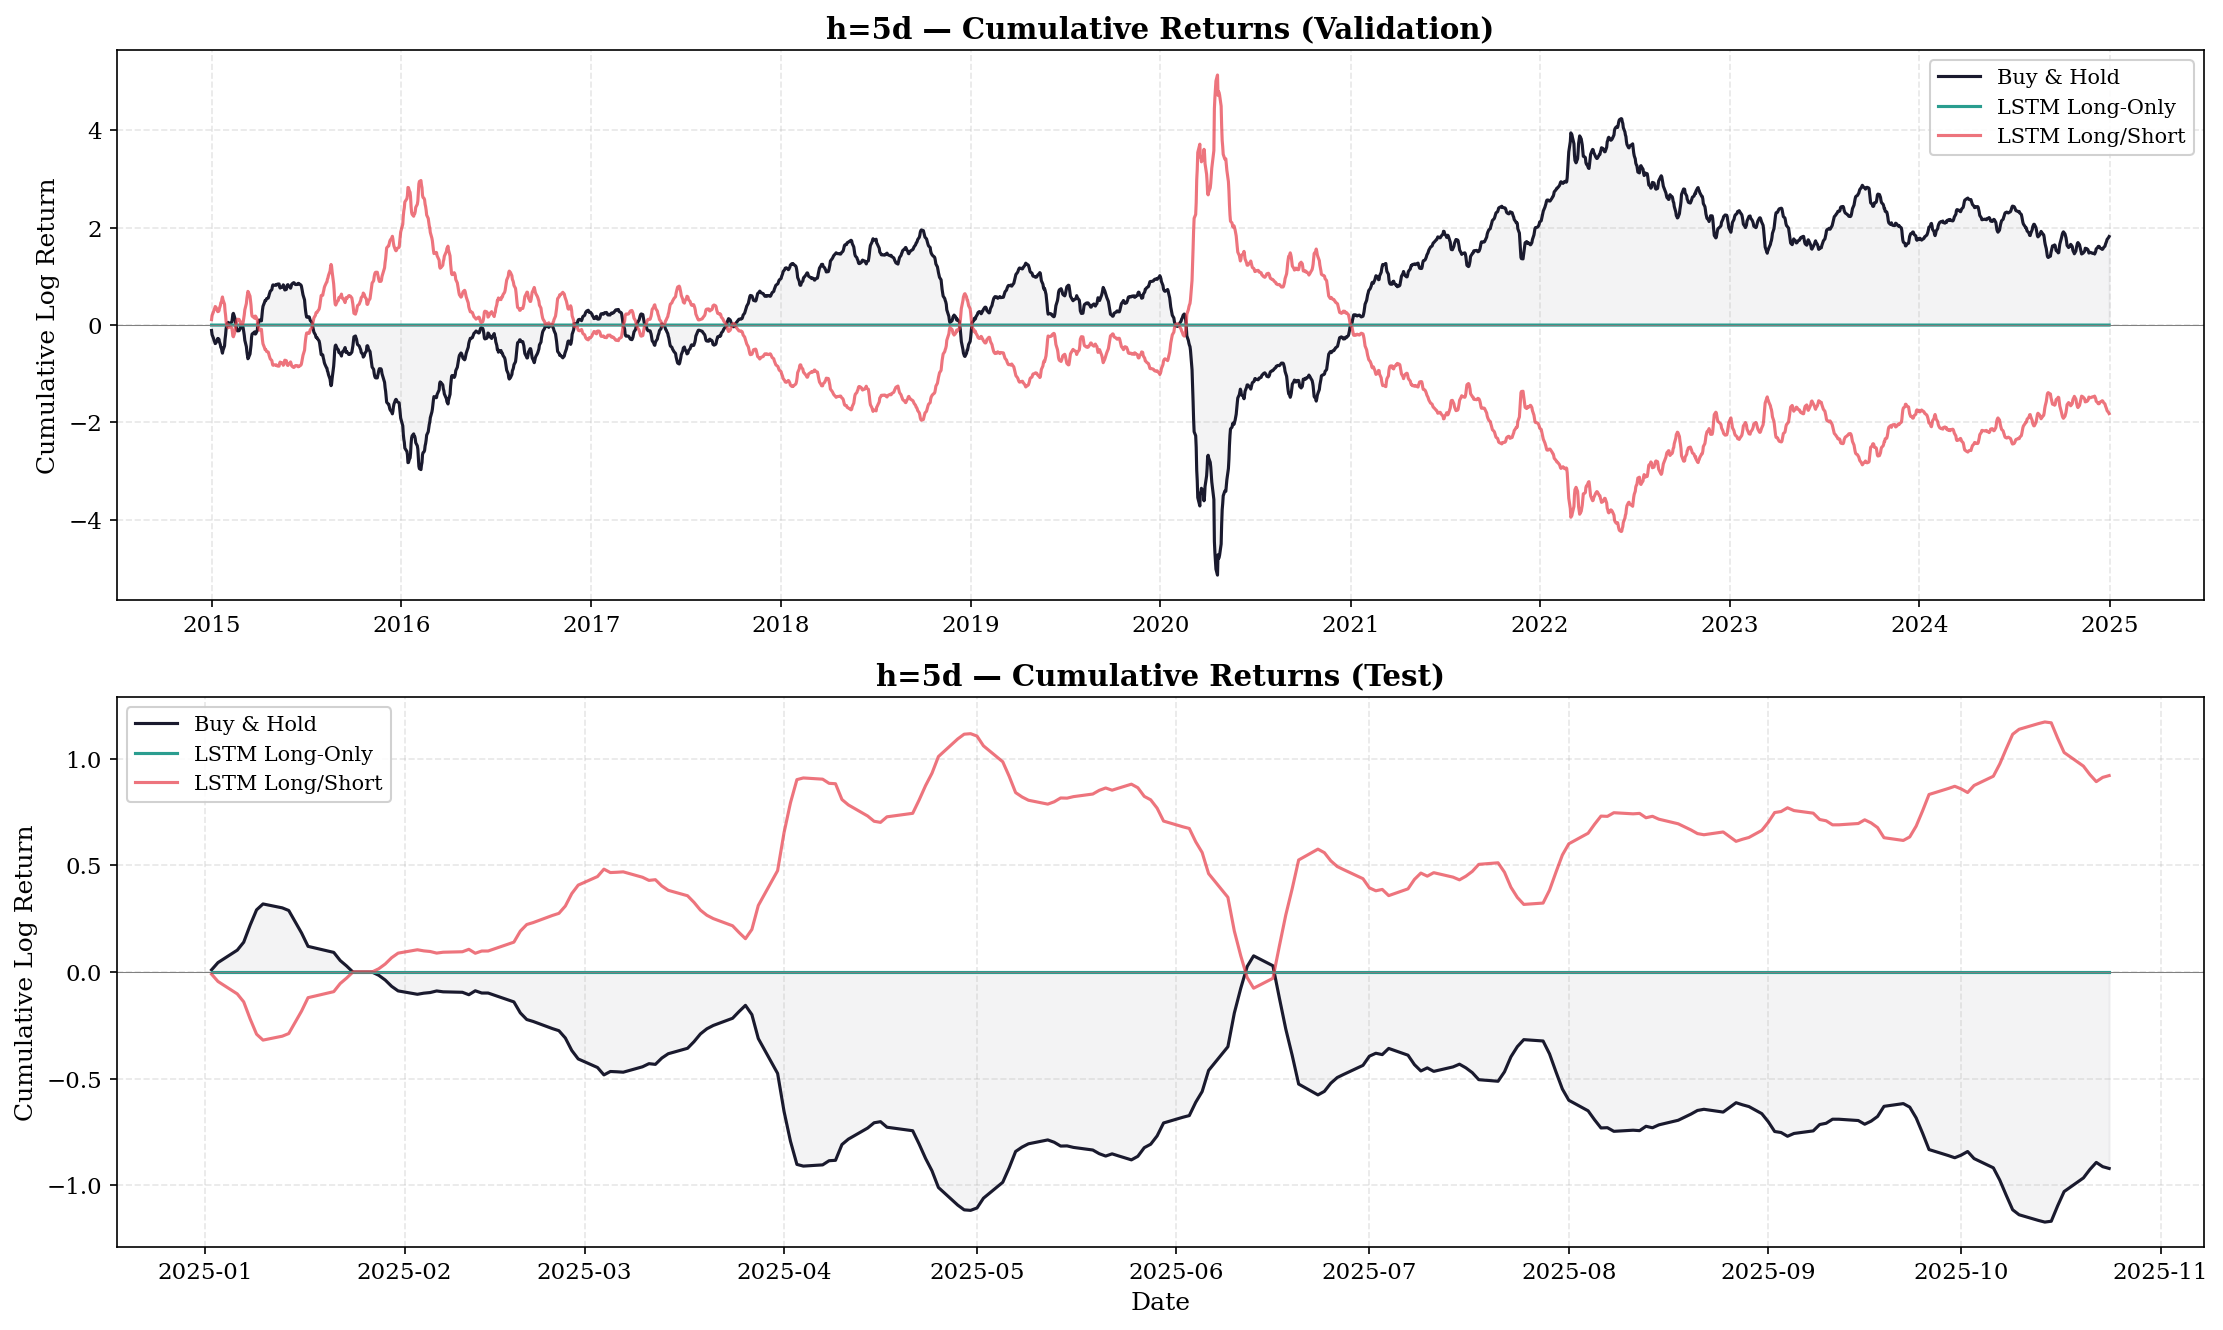

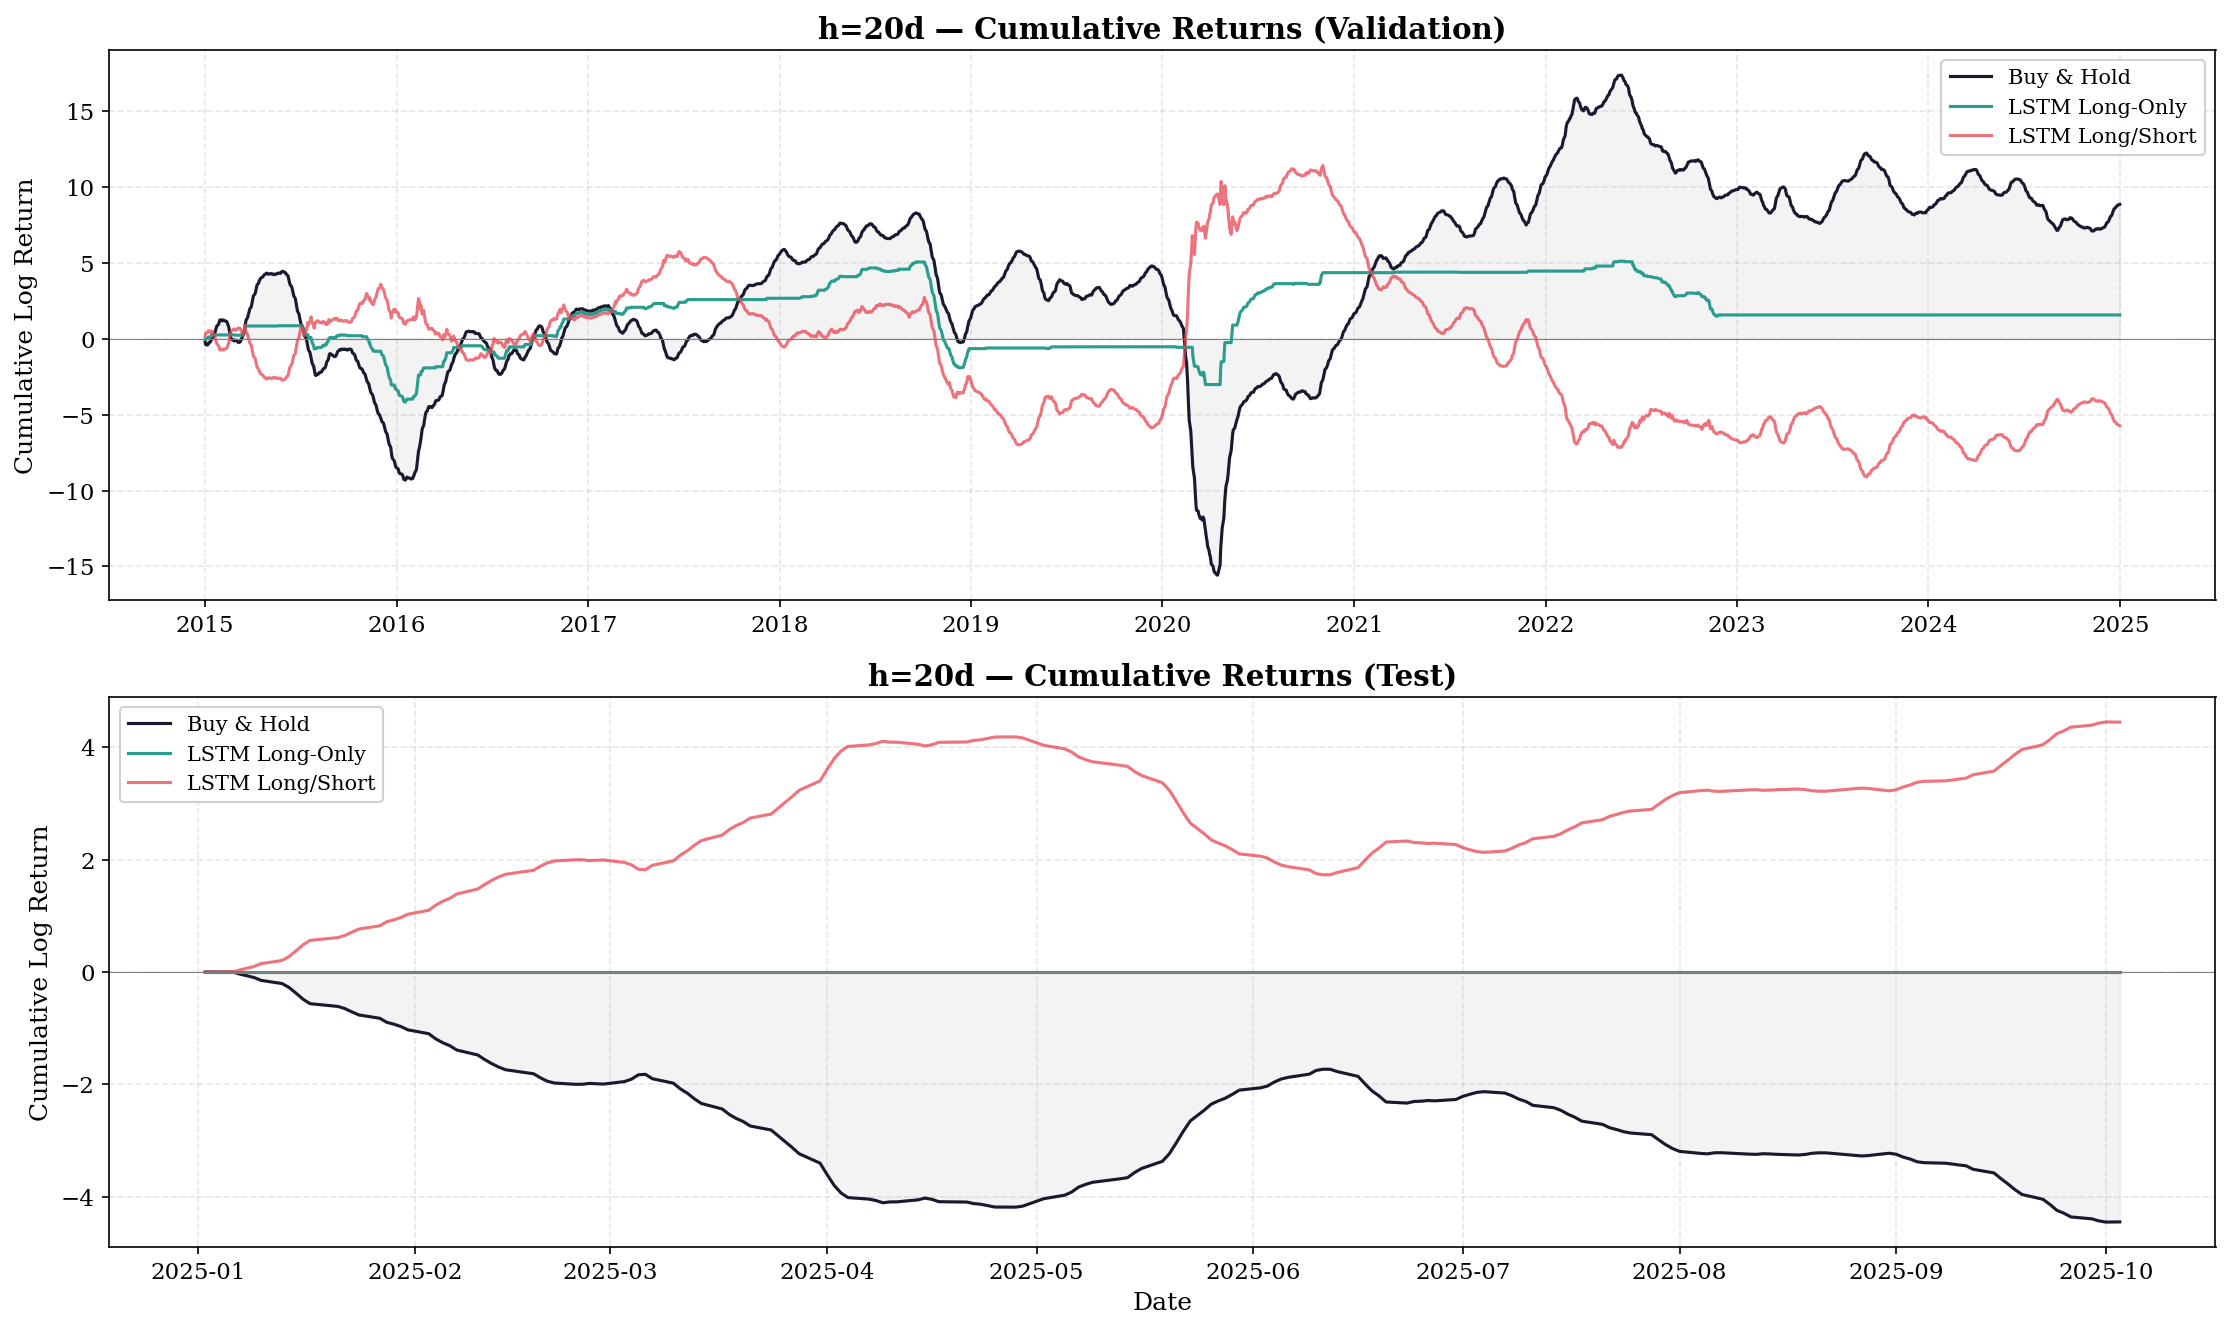

In [19]:
# ============================================================
# Cumulative Returns — Buy & Hold vs LSTM Strategy
# ============================================================
for h in HORIZONS:
    r = results[h]
    fig, axes = plt.subplots(2, 1, figsize=(15, 9))

    for ax, dates, yt, yp, label in [
        (axes[0], r['dva'], r['yva'], r['pred_val'], 'Validation'),
        (axes[1], r['dte'], r['yte'], r['pred_test'], 'Test'),
    ]:
        cum_bh   = np.cumsum(yt)                              # buy & hold
        cum_long = np.cumsum(np.where(yp > 0, yt, 0))        # long when predicted > 0
        cum_ls   = np.cumsum(np.where(yp > 0, yt, -yt))      # long/short

        ax.plot(dates, cum_bh, color=C['actual'], lw=1.5, label='Buy & Hold')
        ax.plot(dates, cum_long, color=C['pos'], lw=1.5, label='LSTM Long-Only')
        ax.plot(dates, cum_ls, color=C['pred'], lw=1.5, alpha=0.7, label='LSTM Long/Short')
        ax.axhline(0, color='gray', lw=0.5)
        ax.fill_between(dates, cum_bh, alpha=0.05, color=C['actual'])
        ax.set_title(f'h={h}d — Cumulative Returns ({label})', fontweight='bold')
        ax.set_ylabel('Cumulative Log Return')
        ax.legend(loc='best', framealpha=0.9)

    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

## 18. Rolling Directional Accuracy
Plot directional accuracy over a rolling window to check if the model has **any periods** of sustained predictive power, even if the overall average is near 50%. Consistent periods above 50% (green shading) would suggest regime-dependent skill; random oscillation around 50% confirms no persistent signal.

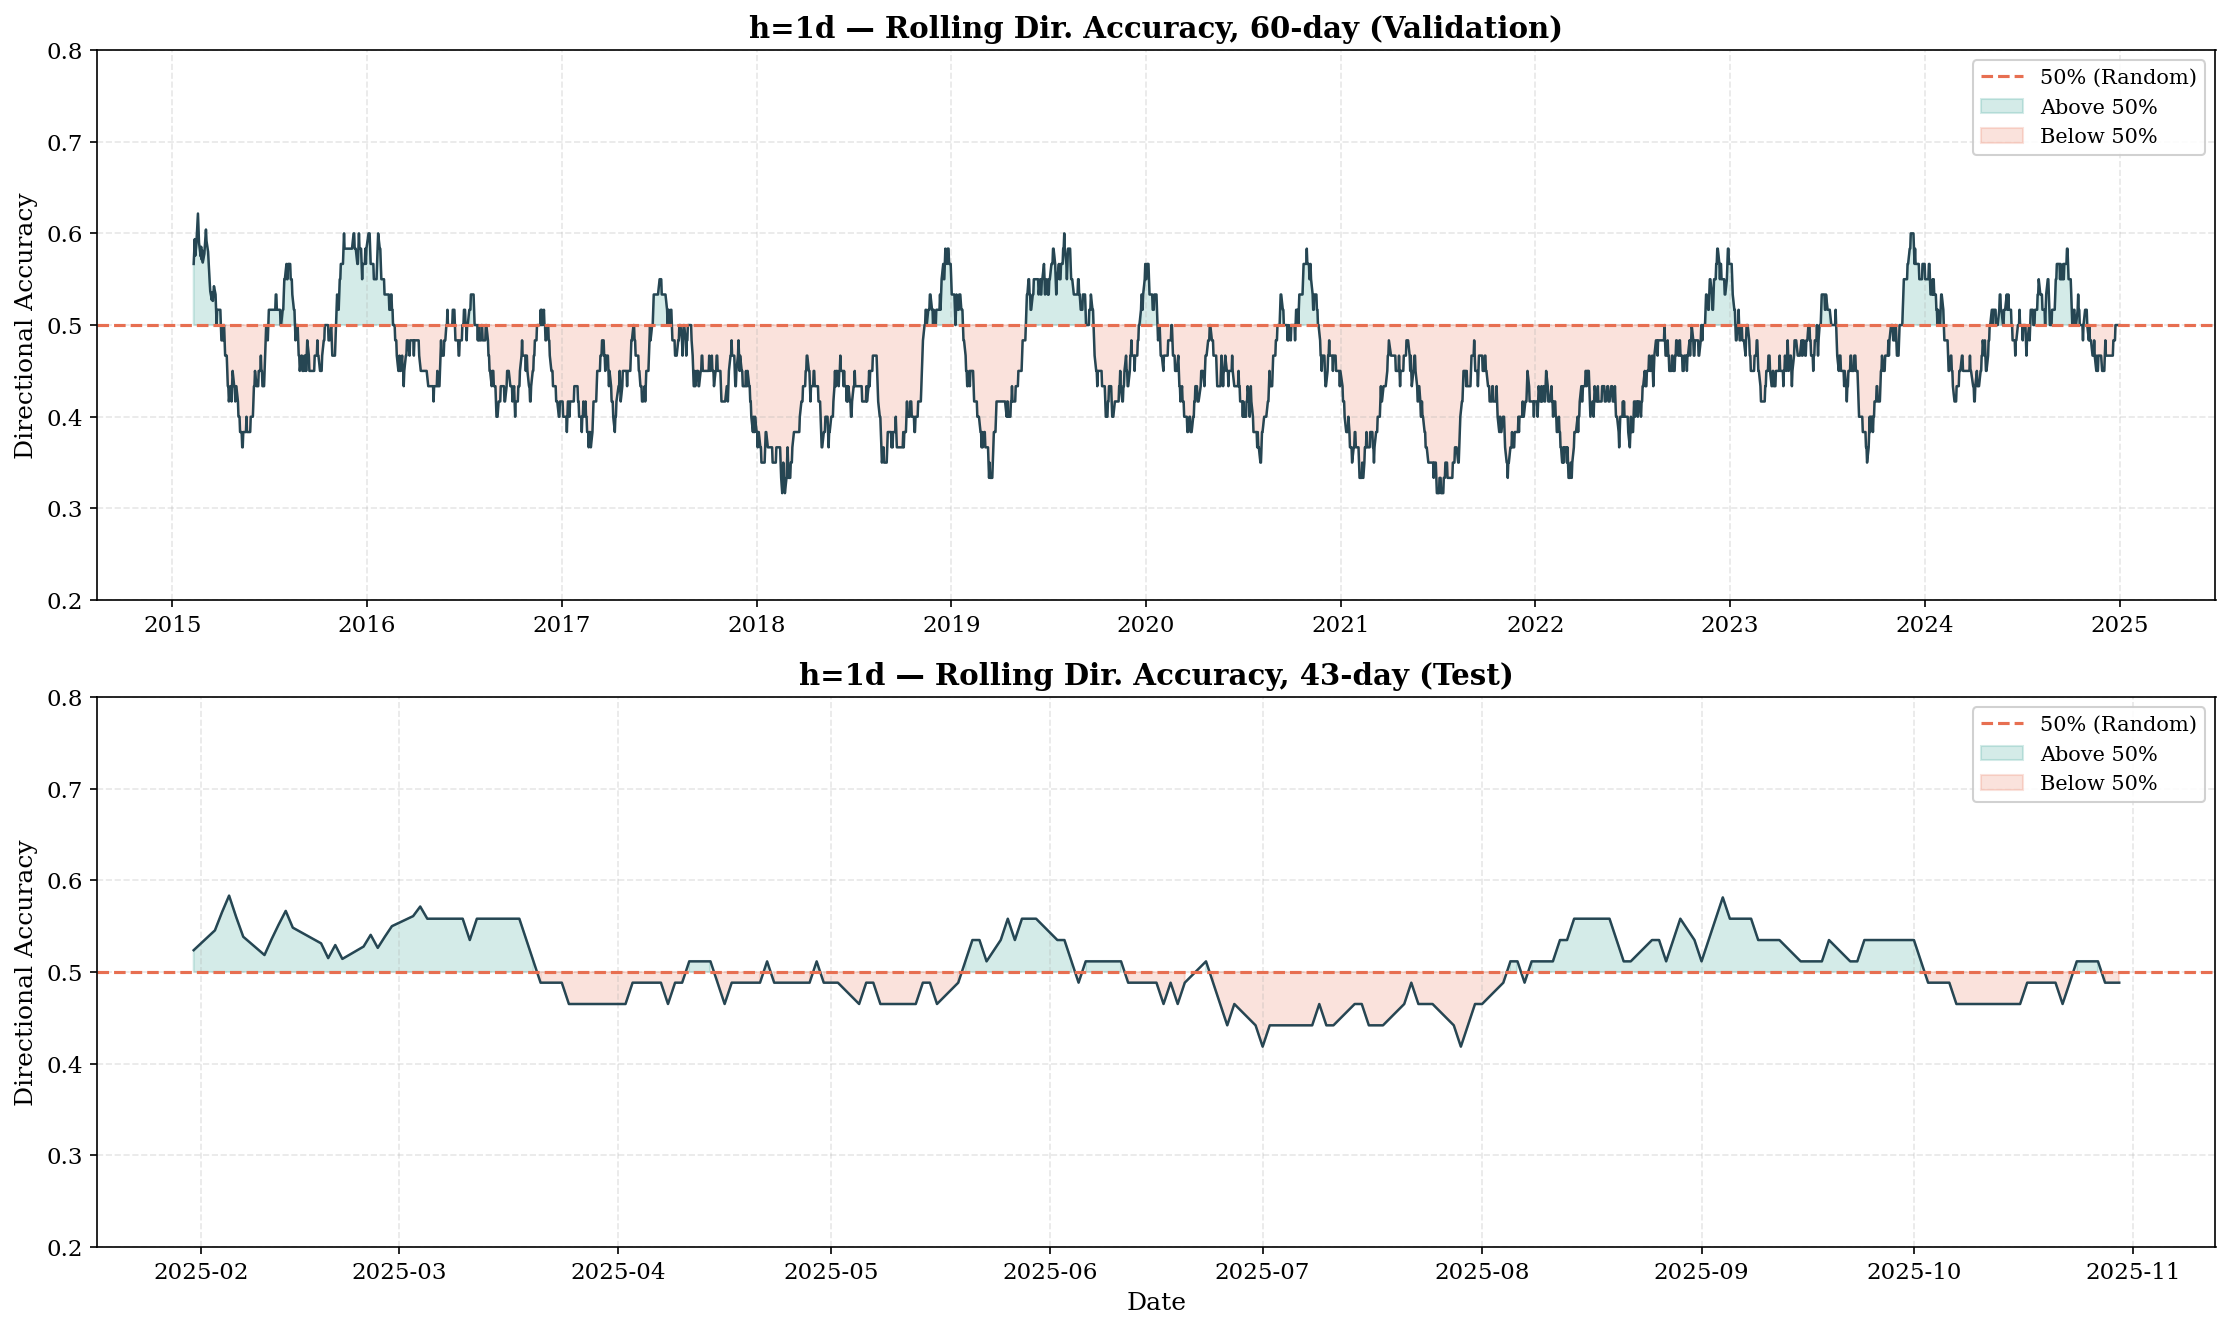

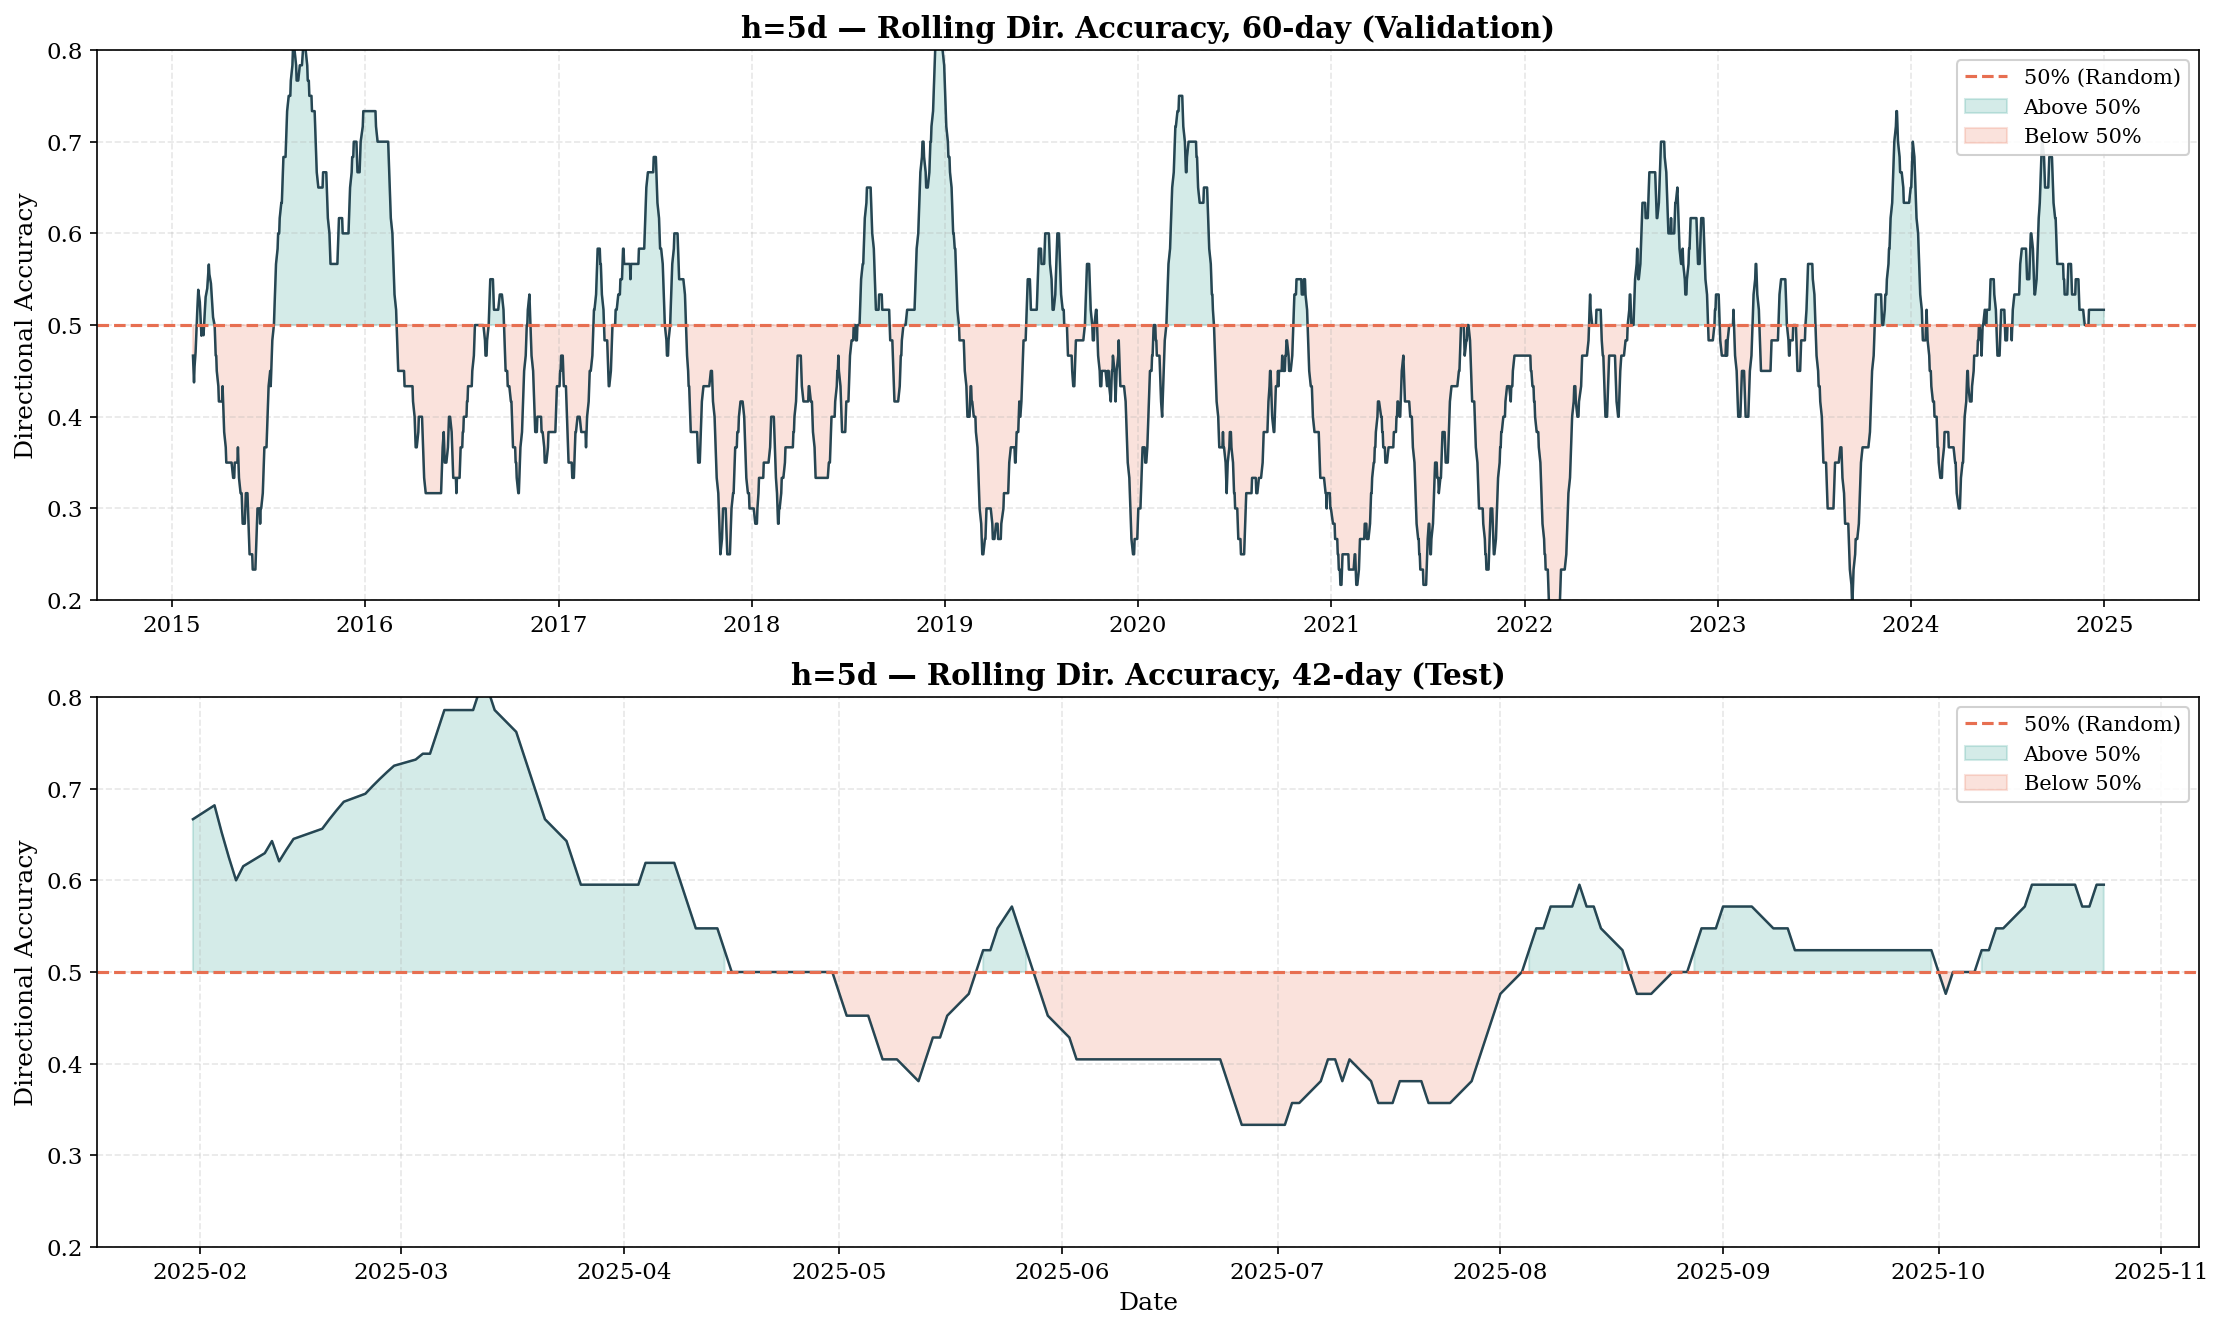

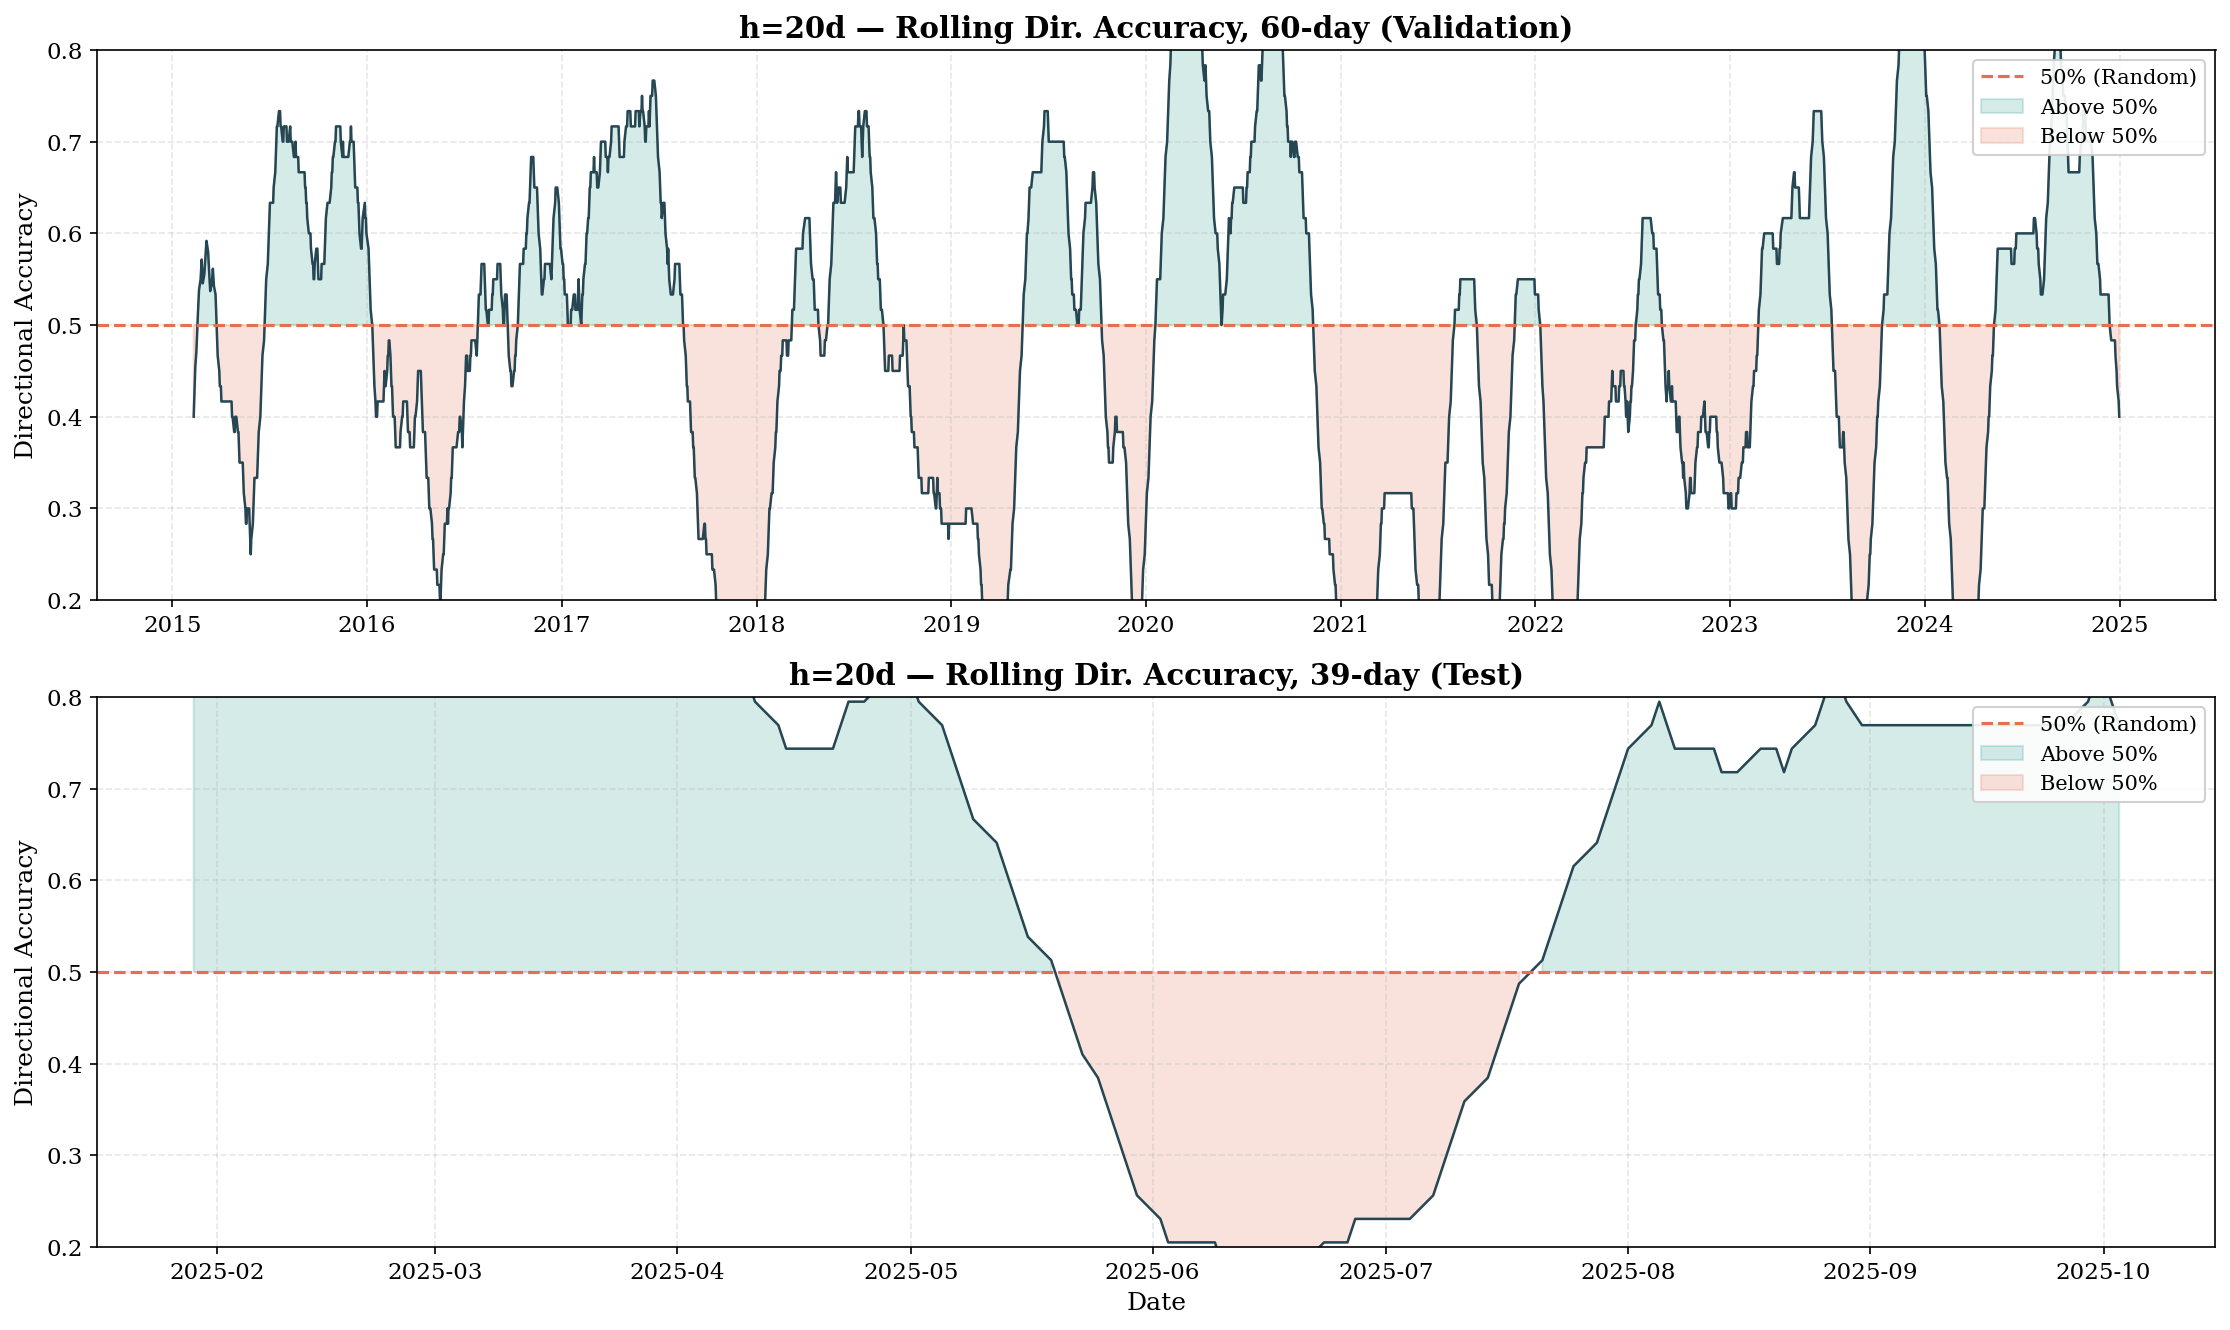

In [20]:
# ============================================================
# Rolling Directional Accuracy
# ============================================================
for h in HORIZONS:
    r = results[h]
    fig, axes = plt.subplots(2, 1, figsize=(15, 9))

    for ax, dates, yt, yp, label, win in [
        (axes[0], r['dva'], r['yva'], r['pred_val'], 'Validation', 60),
        (axes[1], r['dte'], r['yte'], r['pred_test'], 'Test',
         max(10, len(r['yte'])//5)),
    ]:
        correct = (np.sign(yt) == np.sign(yp)).astype(float)
        rolling = pd.Series(correct, index=dates).rolling(win, min_periods=win//2).mean()

        ax.plot(dates, rolling, color=C['h1'], lw=1.2)
        ax.axhline(0.5, color=C['neg'], lw=1.5, ls='--', label='50% (Random)')
        ax.fill_between(dates, rolling, 0.5, where=rolling > 0.5,
                        alpha=0.2, color=C['pos'], label='Above 50%')
        ax.fill_between(dates, rolling, 0.5, where=rolling <= 0.5,
                        alpha=0.2, color=C['neg'], label='Below 50%')
        ax.set_ylim(0.2, 0.8)
        ax.set_title(f'h={h}d — Rolling Dir. Accuracy, {win}-day ({label})',
                     fontweight='bold')
        ax.set_ylabel('Directional Accuracy')
        ax.legend(loc='upper right', framealpha=0.9)

    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

## 19. Cross-Validation Heatmaps
Visualize the full hyperparameter search space. Each cell shows the mean CV RMSE for one (hidden_size × num_layers) and (dropout × learning_rate) combination. The green border highlights the best configuration. This helps identify whether the model is sensitive to specific hyperparameters — a mostly uniform heatmap suggests the LSTM's performance ceiling is limited by the data, not the architecture.

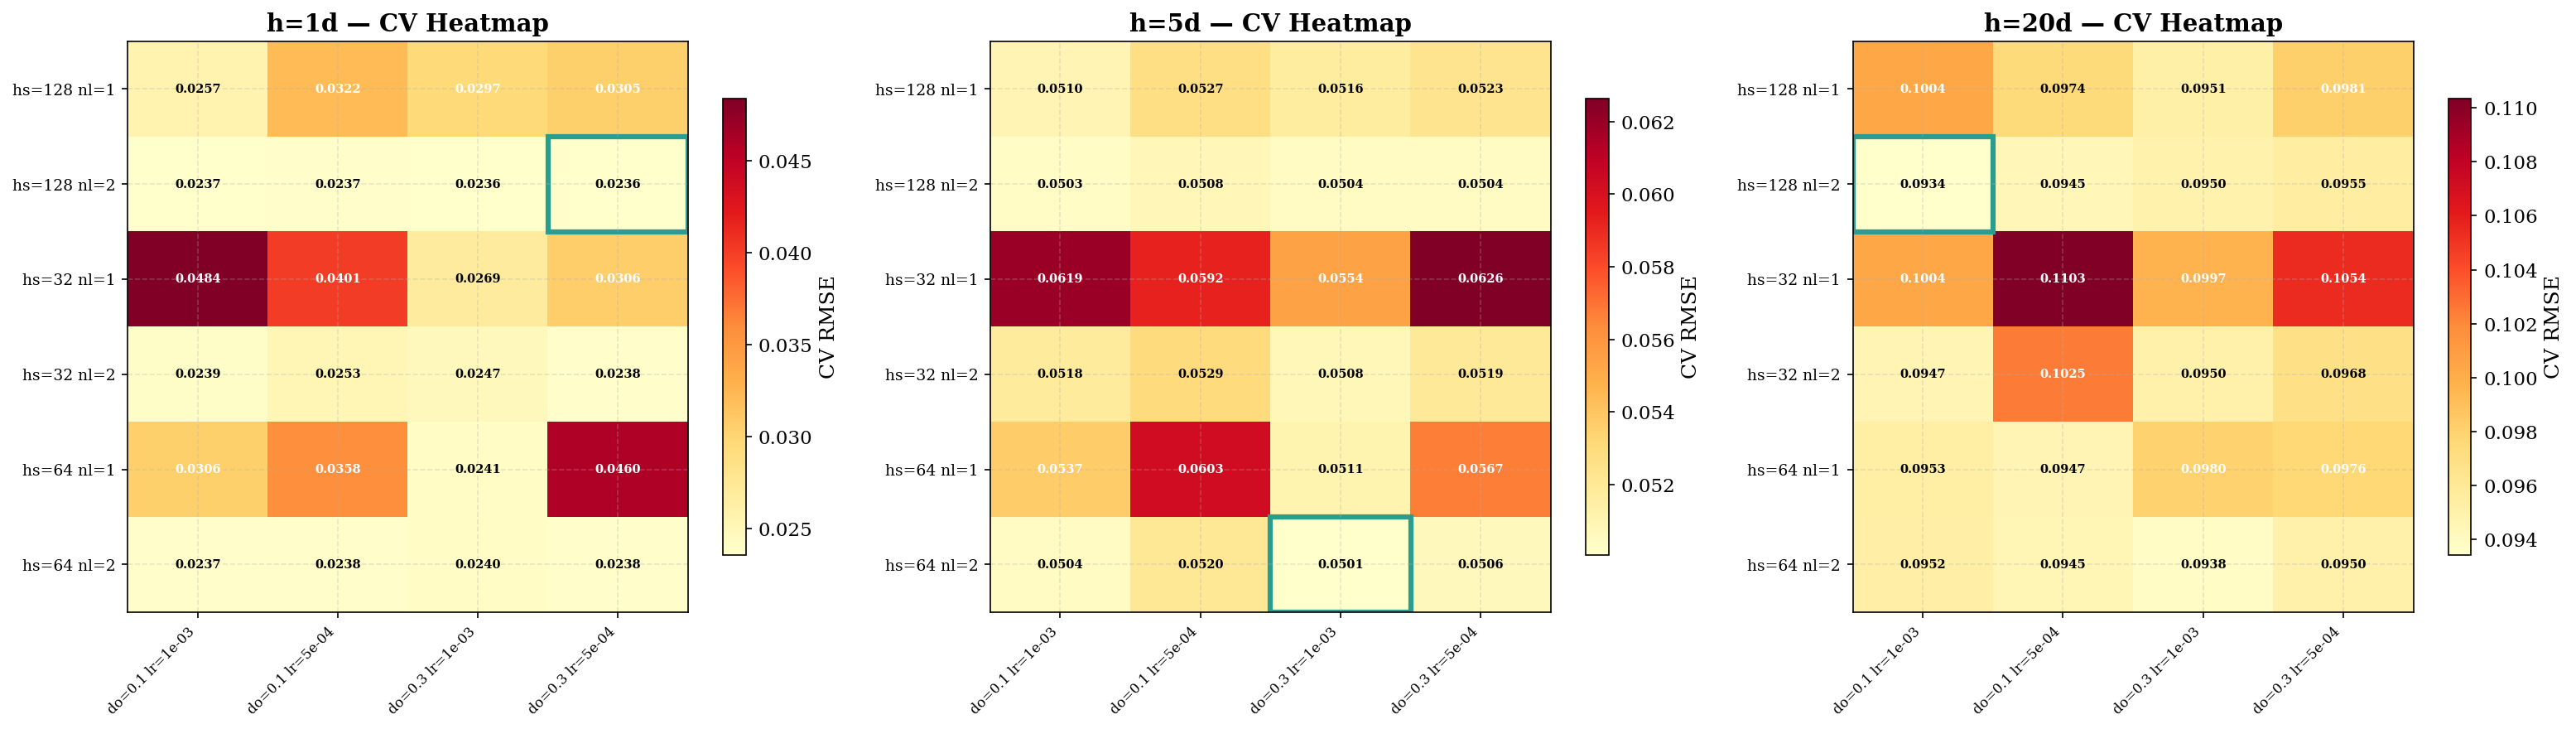

In [21]:
# ============================================================
# CV Heatmaps
# ============================================================
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(7*len(HORIZONS), 6))
if len(HORIZONS) == 1: axes = [axes]

for ax, h in zip(axes, HORIZONS):
    cv = results[h]['model'].cv_results_
    df = pd.DataFrame(cv)

    df['row'] = 'hs=' + df['hidden_size'].astype(str) + ' nl=' + df['num_layers'].astype(str)
    df['col'] = 'do=' + df['dropout'].astype(str) + ' lr=' + df['lr'].apply(lambda x: f'{x:.0e}')
    pivot = df.pivot(index='row', columns='col', values='cv_rmse')

    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)

    # Annotate cells with RMSE values
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            color = 'white' if val > pivot.values.mean() else 'black'
            ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                    fontsize=7, color=color, fontweight='bold')

    # Highlight best config
    bi = np.unravel_index(pivot.values.argmin(), pivot.values.shape)
    ax.add_patch(plt.Rectangle((bi[1]-0.5, bi[0]-0.5), 1, 1,
                 fill=False, edgecolor=C['pos'], lw=3))
    plt.colorbar(im, ax=ax, label='CV RMSE', shrink=0.8)
    ax.set_title(f'h={h}d — CV Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

## 20. Multi-Horizon Comparison — Bar Chart
Side-by-side comparison of all four metrics across horizons and splits. Key things to look for:
- **RMSE/MAE**: Increases with horizon (expected — longer-horizon returns have higher variance)
- **R²**: Negative across all horizons = worse than predicting the mean
- **Directional Accuracy**: The 50% dashed line marks the random baseline — values near or below 50% confirm no directional skill

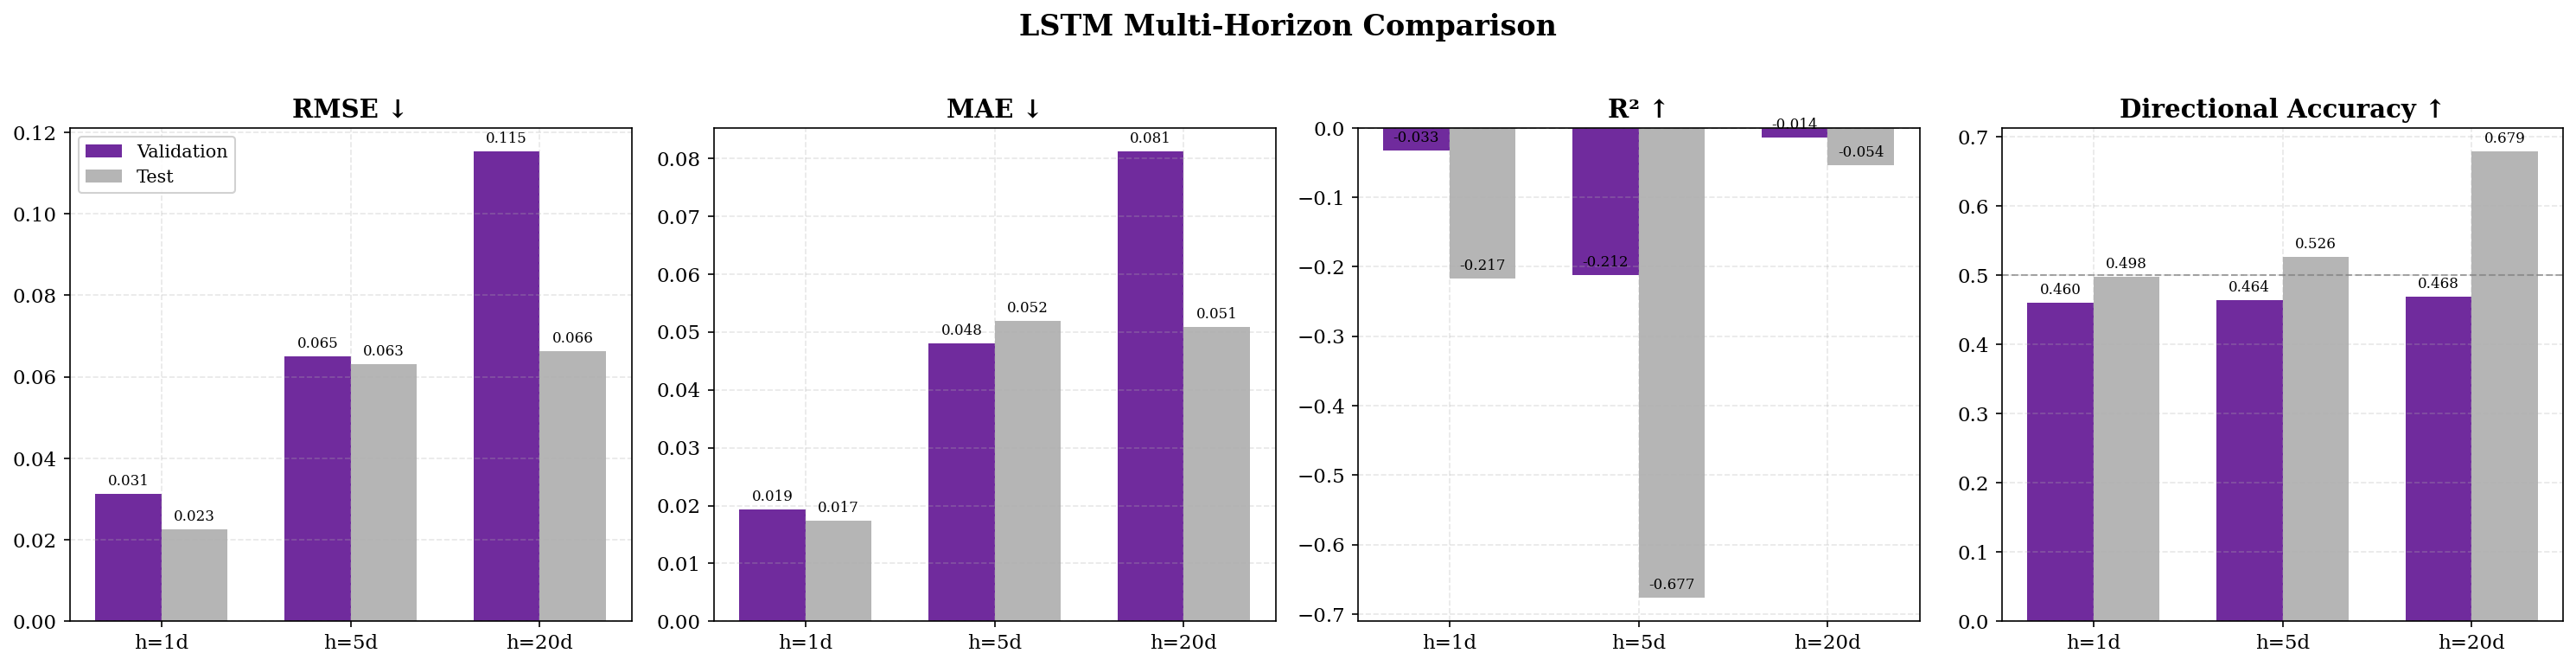

In [22]:
# ============================================================
# Multi-Horizon Comparison Bar Chart
# ============================================================
met_names = ['rmse', 'mae', 'r2', 'directional_acc']
titles = ['RMSE ↓', 'MAE ↓', 'R² ↑', 'Directional Accuracy ↑']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.arange(len(HORIZONS))
w = 0.35

for i, (mn, title) in enumerate(zip(met_names, titles)):
    ax = axes[i]
    vv = [results[h]['val_metrics'][mn] for h in HORIZONS]
    tv = [results[h]['test_metrics'][mn] for h in HORIZONS]

    b1 = ax.bar(x - w/2, vv, w, label='Validation', color="#57068c", alpha=0.85)
    b2 = ax.bar(x + w/2, tv, w, label='Test', color='#a8a8a8', alpha=0.85)

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'h={h}d' for h in HORIZONS])

    if mn == 'directional_acc':
        ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.7)
    elif mn == 'r2':
        ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.7)

    for bar in list(b1) + list(b2):
        ht = bar.get_height()
        ax.annotate(f'{ht:.3f}', xy=(bar.get_x()+bar.get_width()/2, ht),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)
    if i == 0: ax.legend(framealpha=0.9)

plt.suptitle('LSTM Multi-Horizon Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 21. Final Summary
Clean tabular output of all results for easy inclusion in the report, along with the best hyperparameter configuration selected for each horizon.

In [22]:
# ============================================================
# Summary Table
# ============================================================
rows = []
for h in HORIZONS:
    for sn, mk in [('Val', 'val_metrics'), ('Test', 'test_metrics')]:
        m = results[h][mk]
        rows.append({
            'Horizon': f'{h}d', 'Split': sn,
            'RMSE': f"{m['rmse']:.6f}", 'MAE': f"{m['mae']:.6f}",
            'R²': f"{m['r2']:.6f}", 'Dir. Acc': f"{m['directional_acc']:.4f}",
        })

summary = pd.DataFrame(rows)
print('\n' + '='*65)
print('  LSTM Multi-Horizon Results Summary')
print('='*65)
print(summary.to_string(index=False))
print('='*65)

print('\nBest Hyperparameters:')
for h in HORIZONS:
    bp = results[h]['model'].best_params_
    print(f"  h={h:>2}d: hs={bp['hidden_size']}, nl={bp['num_layers']}, "
          f"do={bp['dropout']}, lr={bp['lr']}, cv_rmse={bp['cv_rmse']:.6f}")


  LSTM Multi-Horizon Results Summary
Horizon Split     RMSE      MAE        R² Dir. Acc
     1d   Val 0.032735 0.021516 -0.124438   0.4679
     1d  Test 0.024696 0.019494 -0.450807   0.4977
     5d   Val 0.064929 0.047706 -0.210736   0.4641
     5d  Test 0.051194 0.039324 -0.105096   0.5261
    20d   Val 0.129004 0.097536 -0.269033   0.4497
    20d  Test 0.091170 0.070809 -0.998929   0.6786

Best Hyperparameters:
  h= 1d: hs=128, nl=2, do=0.3, lr=0.0005, cv_rmse=0.023595
  h= 5d: hs=128, nl=2, do=0.3, lr=0.001, cv_rmse=0.050240
  h=20d: hs=64, nl=2, do=0.1, lr=0.001, cv_rmse=0.093628
